In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from scipy.stats import pearsonr
from statannotations.Annotator import Annotator
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score


metrics_df = pd.read_csv("../data/12k_all_metrics.csv")
metrics_df["closest_ab_pident"] = metrics_df["closest_ab_pident"].fillna(0)
metrics_df["ubiquitin_pident"] = metrics_df["ubiquitin_pident"].fillna(0)

results_df = pd.read_csv("../data/12k_all_results.csv")
results_df["leah_12k_Significant"] = results_df["leah_12k_Significant"].fillna(False)


# results_df.columns
# results_df["leah_12k_2fold_threshold"].fillna("Not Sig") # I don't think we can fill the rest! and im not even sure this is valid

# # print cols with nan values
# for col in metrics_df.columns:
#     if metrics_df[col].isna().sum() > 0:
#         print(f"{col}: {metrics_df[col].isna().sum()}")

# # describe each value too
# for col in metrics_df.columns:
#     if metrics_df[col].isna().sum() > 0:
#         print(metrics_df[col].describe())
#         print()
#         print()

/tmp/ipykernel_856375/3135224908.py:19: DtypeWarning: Columns (107) have mixed types. Specify dtype option on import or set low_memory=False.
  metrics_df = pd.read_csv("../data/12k_all_metrics.csv")
/tmp/ipykernel_856375/3135224908.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_df["leah_12k_Significant"] = results_df["leah_12k_Significant"].fillna(False)


In [2]:
def compute_human_frequencies():
    human_freqs = Counter()
    total_aa = 0
    with open("../data/homo_sapiens_UP000005640_9606.fasta", "r") as f:
        seq_parts = []
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq_parts:
                    seq = "".join(seq_parts)
                    human_freqs.update(seq)
                    total_aa += len(seq)
                    seq_parts = []
            else:
                seq_parts.append(line)

        if seq_parts:
            seq = "".join(seq_parts)
            human_freqs.update(seq)
            total_aa += len(seq)

    freqs = {aa: human_freqs[aa] / total_aa for aa in human_freqs}
    return freqs

human_freqs = compute_human_frequencies()

palette = {
    "Down": "#009E73",
    "Not Sig": "#D55E00",
    "Up": "#0072B2",
    "Not Recovered": "#F0E442",
}


In [3]:
teams_df = pd.read_csv("../data/good/master_data_teams.csv")
team_leah_detected = results_df.groupby("team")["leah_12k_detected"].sum()
teams_df = pd.merge(teams_df, team_leah_detected.rename("leah_12k_detected"), left_on="team", right_index=True, how="left")
teams_df["percentage_of_leah_detected"] = teams_df["leah_12k_detected"] / teams_df["number_of_unique_seqs_submitted"]

/tmp/ipykernel_856375/296166457.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_856375/296166457.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_856375/296166457.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_856375/296166457.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


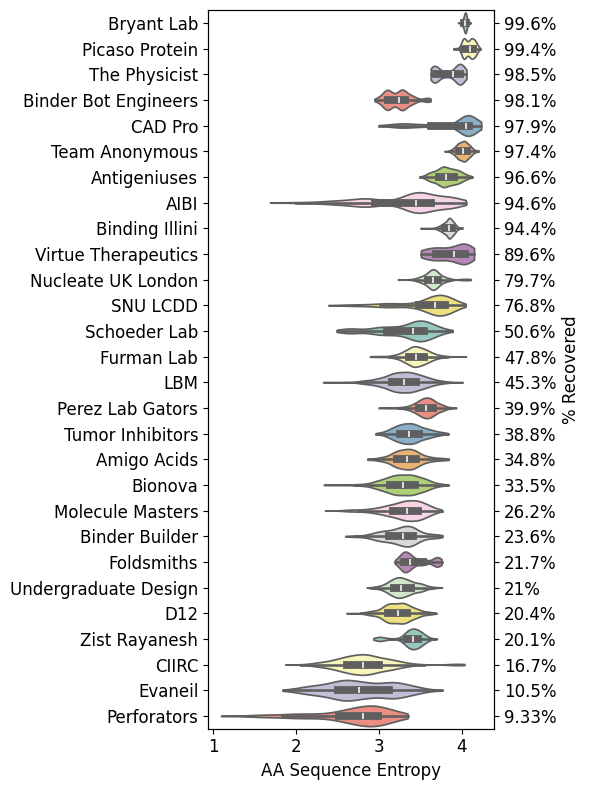

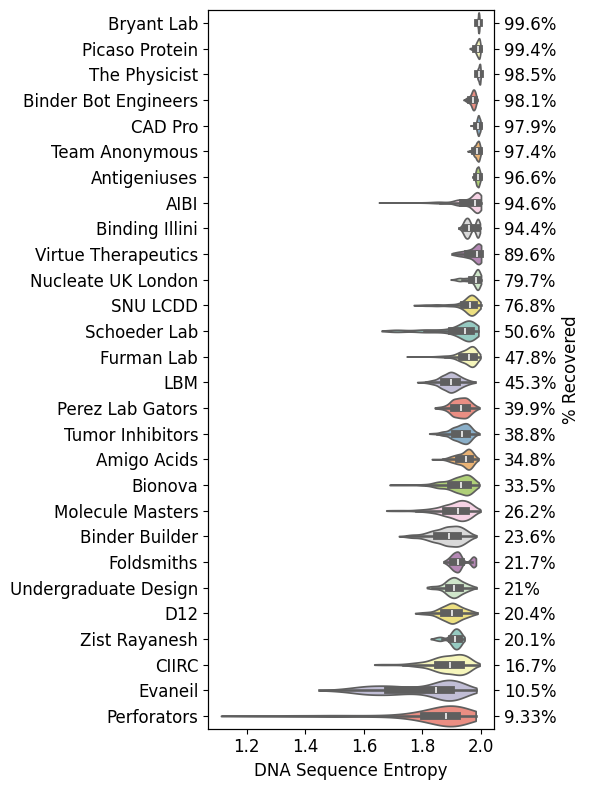

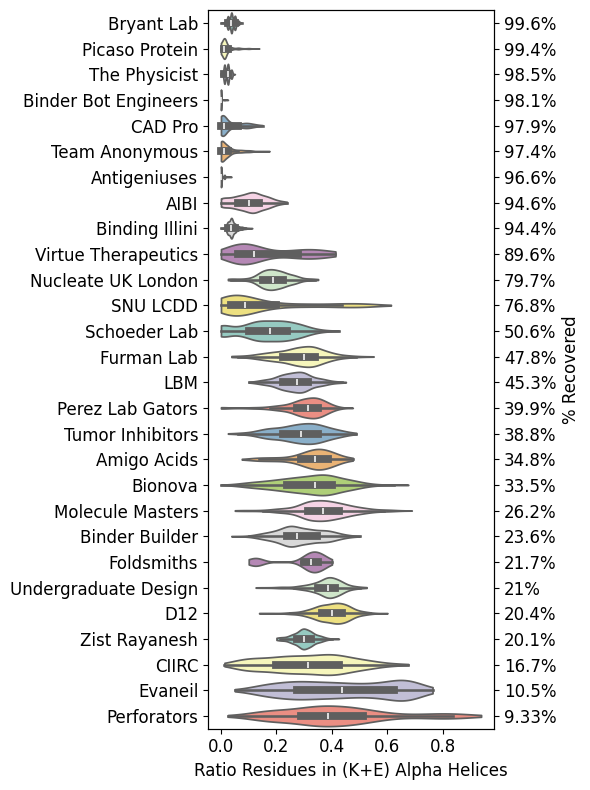

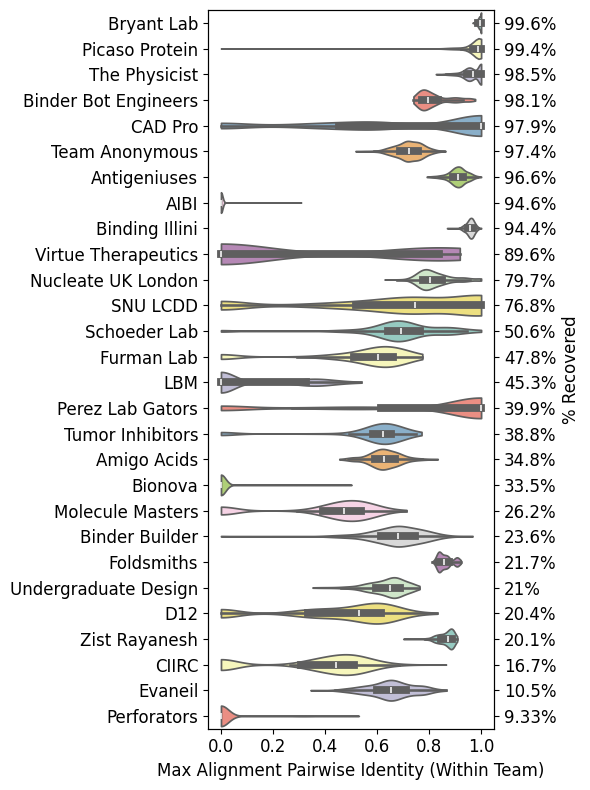

In [4]:
# Build lookup and team order based on LEAH detection
team_pct = teams_df.set_index("team")["percentage_of_leah_detected"]
sorted_teams = team_pct.sort_values(ascending=False).index

# AA entropy
team_entropy = (
    metrics_df.groupby("team")["aa_sequence_entropy"]
    .apply(list)
    .explode()
    .reset_index()
)
team_entropy = pd.merge(team_entropy, teams_df, on="team", how="left")

team_entropy["team"] = pd.Categorical(team_entropy["team"], categories=sorted_teams, ordered=True)
team_entropy = team_entropy.sort_values("team")

plt.figure(figsize=(6, 8))
ax = sns.violinplot(
    data=team_entropy,
    y="team",
    x="aa_sequence_entropy",
    palette="Set3",
    cut=0,
)
plt.xlabel("AA Sequence Entropy", fontsize=12)
plt.ylabel("")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

teams_in_plot = [t.get_text() for t in ax.get_yticklabels()]
pct_labels = [f"{team_pct[t] * 100:.3g}%" for t in teams_in_plot]

ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels(pct_labels, fontsize=12)
ax2.set_ylabel("% Recovered", fontsize=12)

plt.tight_layout()
plt.savefig("../results/analysis/aa_sequence_entropy_per_team_violin_leahdetected.png", dpi=300)


# DNA entropy
team_entropy = (
    metrics_df.groupby("team")["dna_sequence_entropy"]
    .apply(list)
    .explode()
    .reset_index()
)
team_entropy = pd.merge(team_entropy, teams_df, on="team", how="left")

team_entropy["team"] = pd.Categorical(team_entropy["team"], categories=sorted_teams, ordered=True)
team_entropy = team_entropy.sort_values("team")

plt.figure(figsize=(6, 8))
ax = sns.violinplot(
    data=team_entropy,
    y="team",
    x="dna_sequence_entropy",
    palette="Set3",
    cut=0,
)
plt.xlabel("DNA Sequence Entropy", fontsize=12)
plt.ylabel("")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

teams_in_plot = [t.get_text() for t in ax.get_yticklabels()]
pct_labels = [f"{team_pct[t] * 100:.3g}%" for t in teams_in_plot]

ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels(pct_labels, fontsize=12)
ax2.set_ylabel("% Recovered", fontsize=12)

plt.tight_layout()
plt.savefig("../results/analysis/dna_sequence_entropy_per_team_violin_leahdetected.png", dpi=300)



# Ratio KE
team_entropy = (
    metrics_df.groupby("team")["dssp_ke_alpha_ratio"]
    .apply(list)
    .explode()
    .reset_index()
)
team_entropy = pd.merge(team_entropy, teams_df, on="team", how="left")

team_entropy["team"] = pd.Categorical(team_entropy["team"], categories=sorted_teams, ordered=True)
team_entropy = team_entropy.sort_values("team")

plt.figure(figsize=(6, 8))
ax = sns.violinplot(
    data=team_entropy,
    y="team",
    x="dssp_ke_alpha_ratio",
    palette="Set3",
    cut=0,
)
plt.xlabel("Ratio Residues in (K+E) Alpha Helices", fontsize=12)
plt.ylabel("")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

teams_in_plot = [t.get_text() for t in ax.get_yticklabels()]
pct_labels = [f"{team_pct[t] * 100:.3g}%" for t in teams_in_plot]

ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels(pct_labels, fontsize=12)
ax2.set_ylabel("% Recovered", fontsize=12)

plt.tight_layout()
plt.savefig("../results/analysis/dssp_ke_alpha_ratio_per_team_violin_leahdetected.png", dpi=300)




# Max pident within team hamming
team_entropy = (
    metrics_df.groupby("team")["max_pident_within_team_mmseqs"]
    .apply(list)
    .explode()
    .reset_index()
)
team_entropy = pd.merge(team_entropy, teams_df, on="team", how="left")

team_entropy["team"] = pd.Categorical(team_entropy["team"], categories=sorted_teams, ordered=True)
team_entropy = team_entropy.sort_values("team")

plt.figure(figsize=(6, 8))
ax = sns.violinplot(
    data=team_entropy,
    y="team",
    x="max_pident_within_team_mmseqs",
    palette="Set3",
    cut=0,
)
plt.xlabel("Max Alignment Pairwise Identity (Within Team)", fontsize=12)
plt.ylabel("")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

teams_in_plot = [t.get_text() for t in ax.get_yticklabels()]
pct_labels = [f"{team_pct[t] * 100:.3g}%" for t in teams_in_plot]

ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels(pct_labels, fontsize=12)
ax2.set_ylabel("% Recovered", fontsize=12)

plt.tight_layout()
plt.savefig("../results/analysis/max_pident_within_team_mmseqs_violin_leahdetected.png", dpi=300)

/tmp/ipykernel_856375/2301812075.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_856375/2301812075.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_856375/2301812075.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_856375/2301812075.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


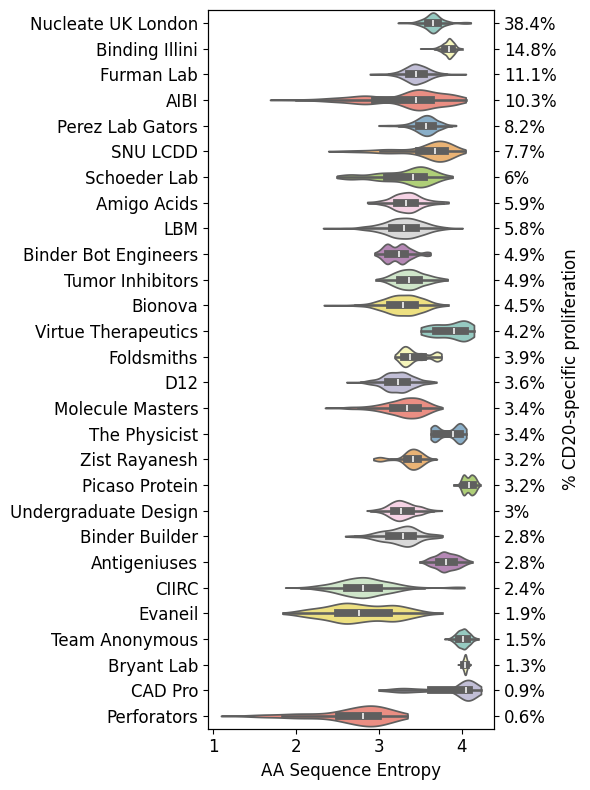

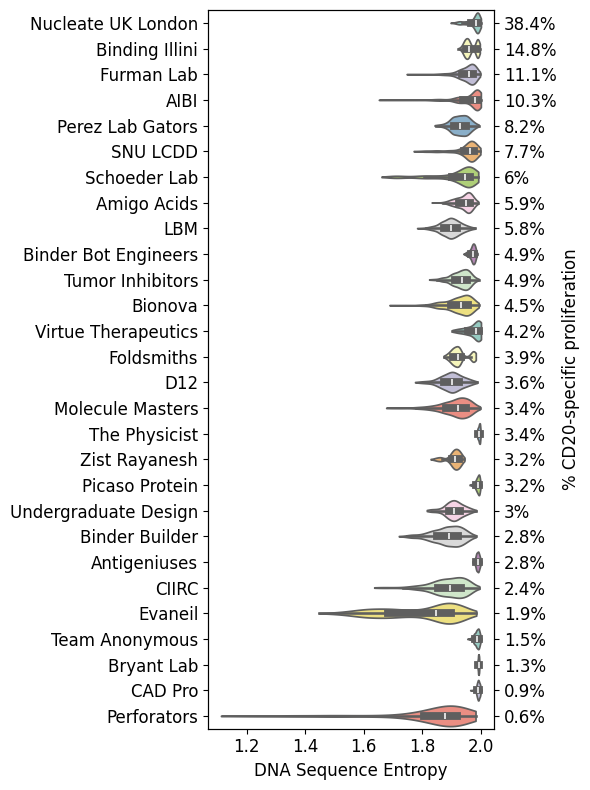

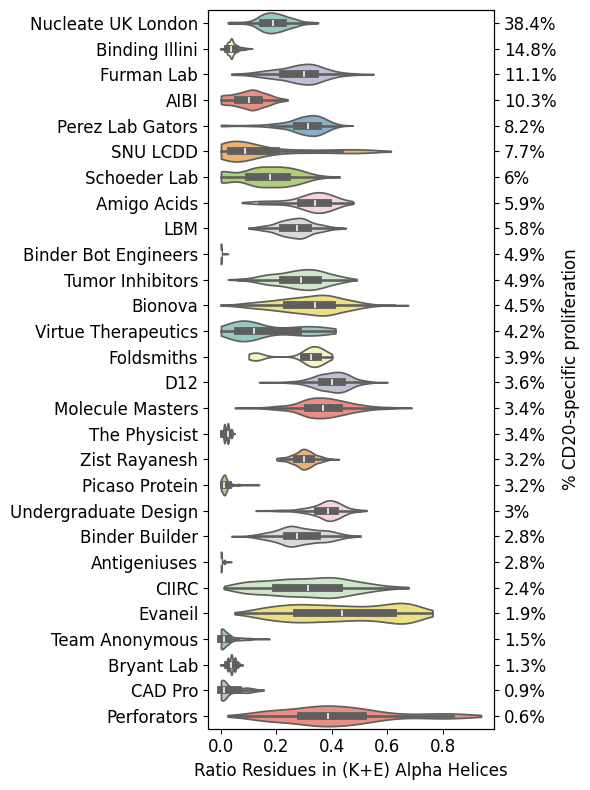

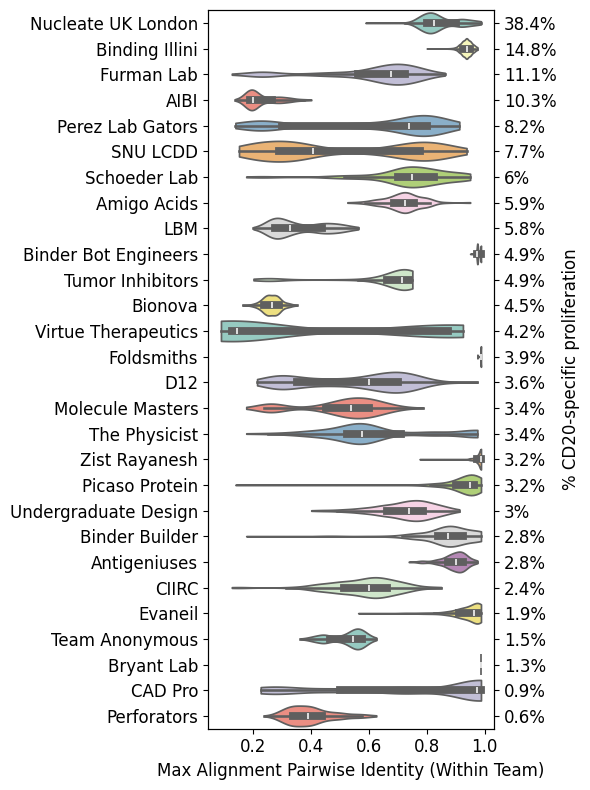

In [5]:
# Build lookup and team order
team_pct = teams_df.set_index("team")["percent_of_significant_seqs"]
sorted_teams = team_pct.sort_values(ascending=False).index

# AA entropy
team_entropy = (
    metrics_df.groupby("team")["aa_sequence_entropy"]
    .apply(list)
    .explode()
    .reset_index()
)
team_entropy = pd.merge(team_entropy, teams_df, on="team", how="left")

team_entropy["team"] = pd.Categorical(team_entropy["team"], categories=sorted_teams, ordered=True)
team_entropy = team_entropy.sort_values("team")

plt.figure(figsize=(6, 8))
ax = sns.violinplot(
    data=team_entropy,
    y="team",
    x="aa_sequence_entropy",
    palette="Set3",
    cut=0,
)
plt.xlabel("AA Sequence Entropy", fontsize=12)
plt.ylabel("")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

teams_in_plot = [t.get_text() for t in ax.get_yticklabels()]
pct_labels = [f"{team_pct[t] * 100:.3g}%" for t in teams_in_plot]

ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels(pct_labels, fontsize=12)
ax2.set_ylabel("% CD20-specific proliferation", fontsize=12)

plt.tight_layout()
plt.savefig("../results/analysis/aa_sequence_entropy_per_team_violin_sigseqs.png", dpi=300)


# DNA entropy
team_entropy = (
    metrics_df.groupby("team")["dna_sequence_entropy"]
    .apply(list)
    .explode()
    .reset_index()
)
team_entropy = pd.merge(team_entropy, teams_df, on="team", how="left")

team_entropy["team"] = pd.Categorical(team_entropy["team"], categories=sorted_teams, ordered=True)
team_entropy = team_entropy.sort_values("team")

plt.figure(figsize=(6, 8))
ax = sns.violinplot(
    data=team_entropy,
    y="team",
    x="dna_sequence_entropy",
    palette="Set3",
    cut=0,
)
plt.xlabel("DNA Sequence Entropy", fontsize=12)
plt.ylabel("")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

teams_in_plot = [t.get_text() for t in ax.get_yticklabels()]
pct_labels = [f"{team_pct[t] * 100:.3g}%" for t in teams_in_plot]

ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels(pct_labels, fontsize=12)
ax2.set_ylabel("% CD20-specific proliferation", fontsize=12)

plt.tight_layout()
plt.savefig("../results/analysis/dna_sequence_entropy_per_team_violin_sigseqs.png", dpi=300)

# Ratio KE
team_entropy = (
    metrics_df.groupby("team")["dssp_ke_alpha_ratio"]
    .apply(list)
    .explode()
    .reset_index()
)
team_entropy = pd.merge(team_entropy, teams_df, on="team", how="left")

team_entropy["team"] = pd.Categorical(team_entropy["team"], categories=sorted_teams, ordered=True)
team_entropy = team_entropy.sort_values("team")

plt.figure(figsize=(6, 8))
ax = sns.violinplot(
    data=team_entropy,
    y="team",
    x="dssp_ke_alpha_ratio",
    palette="Set3",
    cut=0,
)
plt.xlabel("Ratio Residues in (K+E) Alpha Helices", fontsize=12)
plt.ylabel("")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

teams_in_plot = [t.get_text() for t in ax.get_yticklabels()]
pct_labels = [f"{team_pct[t] * 100:.3g}%" for t in teams_in_plot]

ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels(pct_labels, fontsize=12)
ax2.set_ylabel("% CD20-specific proliferation", fontsize=12)

plt.tight_layout()
plt.savefig("../results/analysis/dssp_ke_alpha_ratio_per_team_violin_sigseqs.png", dpi=300)


# within_team pairwise diversityd
team_entropy = (
    metrics_df.groupby("team")["max_pident_within_team_hamming"]
    .apply(list)
    .explode()
    .reset_index()
)
team_entropy = pd.merge(team_entropy, teams_df, on="team", how="left")

team_entropy["team"] = pd.Categorical(team_entropy["team"], categories=sorted_teams, ordered=True)
team_entropy = team_entropy.sort_values("team")

plt.figure(figsize=(6, 8))
ax = sns.violinplot(
    data=team_entropy,
    y="team",
    x="max_pident_within_team_hamming",
    palette="Set3",
    cut=0
)
plt.xlabel("Max Alignment Pairwise Identity (Within Team)", fontsize=12)
plt.ylabel("")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())

teams_in_plot = [t.get_text() for t in ax.get_yticklabels()]
pct_labels = [f"{team_pct[t] * 100:.3g}%" for t in teams_in_plot]

ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels(pct_labels, fontsize=12)
ax2.set_ylabel("% CD20-specific proliferation", fontsize=12)

plt.tight_layout()
plt.savefig("../results/analysis/max_pident_within_team_hamming_violin_sigseqs.png", dpi=300)

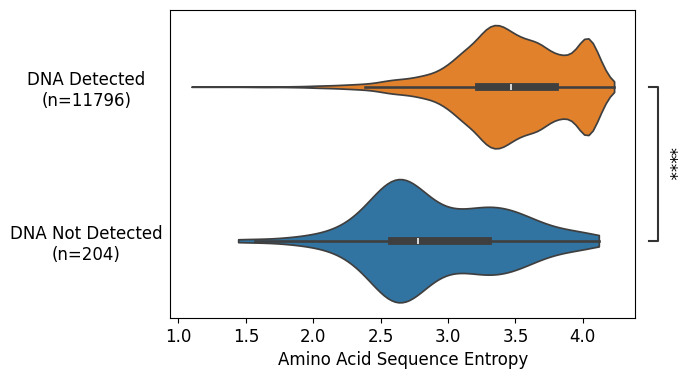

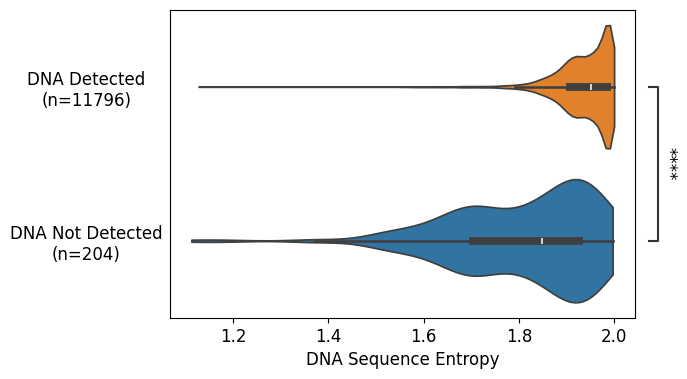

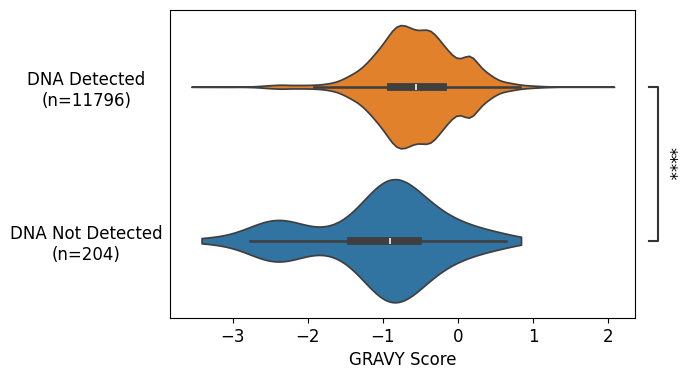

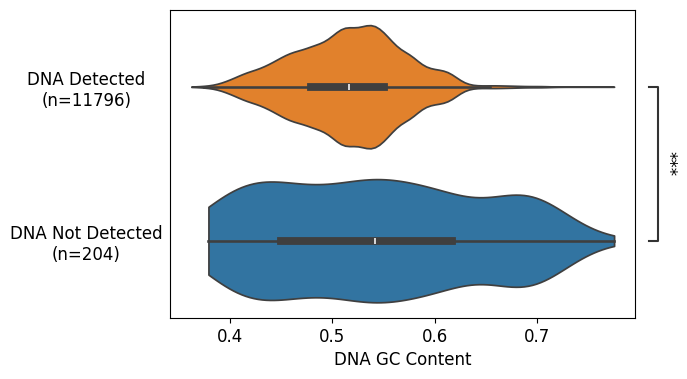

In [6]:
# make a simple violin plot: metrics vs leah_12k_twist_dna_detected

# from statannotations.Annotator import Annotator

def plot_feature_violin_generic(
    feature,
    target_col,
    save_dir="../results/analysis",
    class_order=None,
    class_palette=None,
    feature_labels_map=None,
    y_labels_map=None,
):
    """
    Make a violin plot of a feature vs an arbitrary target column in results_df.
    """

    # values for the feature
    feature_vals = metrics_df[feature].dropna()

    # align target on same index
    target_vals = results_df.loc[feature_vals.index, target_col]

    df = pd.DataFrame(
        {
            feature: feature_vals,
            "target": target_vals,
        },
        index=feature_vals.index,
    ).dropna(subset=[feature, "target"])

    # build class order
    if class_order is None:
        class_order = df["target"].value_counts().index.tolist()

    # normalize everything to string labels so seaborn + palette + y_labels_map agree
    df["target"] = df["target"].astype(str)
    class_order = [str(c) for c in class_order]

    if isinstance(class_palette, dict):
        class_palette = {str(k): v for k, v in class_palette.items()}

    if y_labels_map is not None:
        y_labels_map = {str(k): v for k, v in y_labels_map.items()}

    # make sure target is treated as categorical with the requested order
    df["target"] = pd.Categorical(df["target"], categories=class_order, ordered=True)

    # plotting
    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.violinplot(
        data=df,
        x=feature,
        y="target",
        orient="h",
        order=class_order,
        palette=class_palette,
        hue="target",
        ax=ax,
        cut=0,
        legend=False,
    )

    # counts for each class
    counts = (
        df["target"]
        .value_counts()
        .reindex(class_order)
        .fillna(0)
        .astype(int)
    )

    if y_labels_map is not None:
        new_labels = [
            y_labels_map.get(lab, lab) + f"\n(n={counts[lab]})"
            for lab in class_order
        ]
        ax.set_ylabel("")
    else:
        new_labels = [f"{lab}\n(n={counts[lab]})" for lab in class_order]
        ax.set_ylabel(target_col)

    ax.set_yticks(range(len(class_order)))
    ax.set_yticklabels(new_labels)

    ax.tick_params(axis="y", length=0)

    # x label
    if feature_labels_map is None and "feature_labels" in globals():
        feature_labels_map = feature_labels

    xlabel = (
        feature_labels_map.get(feature, feature)
        if feature_labels_map is not None
        else feature
    )
    ax.set_xlabel(xlabel)

    # center y tick labels and shift left
    for label in ax.get_yticklabels():
        label.set_horizontalalignment("center")
        label.set_x(-0.17)

    # compute sig
    pairs = []
    for i in range(len(class_order)):
        for j in range(i + 1, len(class_order)):
            pairs.append((class_order[i], class_order[j]))

    annotator = Annotator(
        ax,
        pairs,
        data=df,
        y="target",
        x=feature,
        order=class_order,
        orient="h",
    )
    annotator.configure(test="Mann-Whitney", text_format="star", loc="outside", verbose=0)
    annotator.apply_and_annotate()

    feature_safe = feature.replace(" ", "_")
    target_safe = target_col.replace(" ", "_")
    out_path = f"{save_dir}/feature_{feature_safe}_by_{target_safe}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    # plt.close()
# binary target


# dna dup features
for feature in ["aa_sequence_entropy", "dna_sequence_entropy", "gravy_score","dna_gc_content", ]:#"longest_dup_substr_len_dna", "longest_dup_occurrences_dna", "total_duplicated_nucleotides"]:
    plot_feature_violin_generic(
        feature=feature,
        target_col="leah_12k_twist_dna_detected",
        feature_labels_map={"aa_sequence_entropy": "Amino Acid Sequence Entropy", "gravy_score": "GRAVY Score", "dna_gc_content": "DNA GC Content", "dna_sequence_entropy": "DNA Sequence Entropy", "longest_dup_substr_len_dna": "Longest Duplicated Substring Length (DNA)", "longest_dup_substr_dna": "Longest Duplicated Substring (DNA)", "longest_dup_occurrences_dna": "Longest Duplicated Substring Occurrences (DNA)", "total_duplicated_nucleotides": "Total Duplicated Nucleotides"},
        class_order=[True, False],
        # true orange false blue (original matplotlib colors)
        class_palette={True: "#ff7f0e", False: "#1f77b4"},
        y_labels_map={True: "DNA Detected", False: "DNA Not Detected"},
    )


In [7]:
# cols = metrics_df.columns.drop(["team", "global_id", "sequence", "closest_ab"]).tolist()
# # y_metric = "leah_12k_detected"
# y_metric = "twist_dna_read_percentile"

# mi_df = pd.DataFrame()
# for col in cols:
#     pre_len = len(metrics_df)
#     metrics_df_col = metrics_df[[col]].copy()
#     metrics_df_col = metrics_df_col[~metrics_df_col[col].isna()]
#     post_len = len(metrics_df_col)
#     X = metrics_df_col[col].values.reshape(-1, 1)
#     y = results_df.loc[metrics_df_col.index, y_metric].values
#     # mi = mutual_info_classif(
#     #     X,
#     #     y,
#     #     random_state=8387234,
#     #     # n_neighbors=5,
#     #     # discrete_features=False,
#     # )
#     mi = mutual_info_regression(
#         X,
#         y,
#         random_state=8387234,
#         # n_neighbors=5,
#         # discrete_features=False,
#     )
#     sub_df = pd.DataFrame({
#         "metric": col,
#         f"mi_vs_{y_metric}": mi,
#         "num_non_nan": post_len,
#         "num_nan": pre_len - post_len,
#     })
#     mi_df = pd.concat([mi_df, sub_df], axis=0)
# mi_df = mi_df.sort_values(f"mi_vs_{y_metric}", ascending=False).reset_index(drop=True)
# mi_df
# # mi_df.to_csv("../results/analysis/feature_mi_vs_leah_12k_detected.csv", index=False)

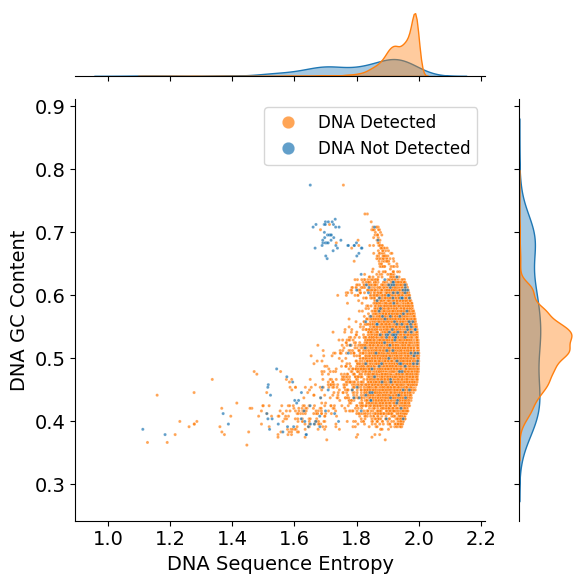

In [8]:

def pretty_label(name):
    return (
        name.replace("_", " ")
            .title()
            .replace("Ll", "Log Likelihood")
            .replace("Car", "CAR")
            .replace("Esm", "ESM")
            .replace("Bc", "BC")
            .replace("Gc", "GC")
            .replace("Dna", "DNA")
    )


def plot_joint_two_features(
    feat_x,
    feat_y,
    metrics_df,
    results_df,
    hue_col="fourclass",          # e.g. "fourclass" or "leah_12k_detected"
    hue_order=None,
    palette=None,
    out_path=None,
):
    # ensure fourclass exists if requested
    if hue_col == "fourclass":
        results_df = ensure_fourclass(results_df)

    # base plotting df
    # add any extras you care about here if needed
    plot_df = metrics_df[[feat_x, feat_y]].copy()
    plot_df = plot_df.dropna(subset=[feat_x, feat_y])
    

    # attach hue column from results_df
    if hue_col == "fourclass":
        h = results_df.loc[plot_df.index, "fourclass"]
        plot_df["hue"] = h
    elif hue_col == "leah_12k_detected":
        # map to nicer labels
        h_raw = results_df.loc[plot_df.index, "leah_12k_detected"].astype(bool)
        plot_df["hue"] = np.where(h_raw, "Detected", "Not Detected")
    else:
        # generic: directly copy that column
        h = results_df.loc[plot_df.index, hue_col]
        plot_df["hue"] = h

    # drop rows with missing hue
    plot_df = plot_df[plot_df["hue"].notna()]

    # default orders and palettes if not provided
    if hue_col == "fourclass":
        default_order = [
            "Not Detected",
            "Not Sig",
            "Up",
            "Down",
        ]
        default_palette = {
            "Down": "#009E73",
            "Not Sig": "#D55E00",
            "Up": "#0072B2",
            "Not Detected": "#F0E442",
        }
        # sort to have nicer layering
        cat_order = {
            "Not Detected": 0,
            "Not Sig": 1,
            "Up": 2,
            "Down": 3,
        }
        plot_df = plot_df.assign(sort_key=plot_df["hue"].map(cat_order))
        plot_df = plot_df.sort_values("sort_key", ascending=True)
    elif hue_col == "leah_12k_detected":
        default_order = ["Detected", "Not Detected"]
        default_palette = {
            "Detected": "#0072B2",
            "Not Detected": "#D55E00",
        }
    else:
        # fall back to sorted unique values and let seaborn choose colors
        default_order = sorted(plot_df["hue"].unique())
        default_palette = None

    if hue_order is None:
        hue_order = default_order
    if palette is None:
        palette = default_palette

    plot_df = plot_df.sort_values(by="hue", ascending=False)

    g = sns.jointplot(
        data=plot_df,
        x=feat_x,
        y=feat_y,
        hue="hue",
        hue_order=hue_order,
        palette=palette,
        kind="scatter",
        s=5,
        alpha=0.7,
        marginal_kws=dict(common_norm=False, fill=True, alpha=0.4),
    )

    # 2d kde plot instead!
    # g = sns.kdeplot(
    #     data=plot_df,
    #     x=feat_x,
    #     y=feat_y,
    #     hue="hue",
    #     hue_order=hue_order,
    #     palette=palette,
    #     fill=False,
    #     common_norm=True,
    #     alpha=0.7,
    #     levels=5,
    #     thresh=0.001,
    #     linewidths=1.5,
    # )
    

    # pretty axis labels
    g.ax_joint.set_xlabel(pretty_label(feat_x), fontsize=14)
    g.ax_joint.set_ylabel(pretty_label(feat_y), fontsize=14)

    g.ax_joint.tick_params(axis="x", labelsize=14)
    g.ax_joint.tick_params(axis="y", labelsize=14)

    

    # legend with larger markers in the right order
    leg = g.ax_joint.get_legend()
    handles = leg.legend_handles
    # g.ax_joint.legend(
    #     handles,
    #     hue_order,
    #     markerscale=4,
    #     fontsize=12,
    #     title="",
    # )

    g.ax_joint.legend(
        handles,
        ["DNA Detected", "DNA Not Detected"],
        markerscale=4,
        fontsize=12,
        title="",
    )

    plt.tight_layout()

    if out_path is None:
        out_path = f"../results/analysis/joint_{feat_x}_{feat_y}_by_{hue_col}.png"

    plt.savefig(out_path, dpi=300)
    # plt.close(g.fig)

# color by binary leah_12k_detected (mapped to "Detected"/"Not Detected")
plot_joint_two_features(
    "dna_sequence_entropy",
    "dna_gc_content",
    metrics_df,
    results_df,
    hue_col="leah_12k_twist_dna_detected",
    hue_order=[True, False],
    palette={True: "#ff7f0e", False: "#1f77b4"},
)

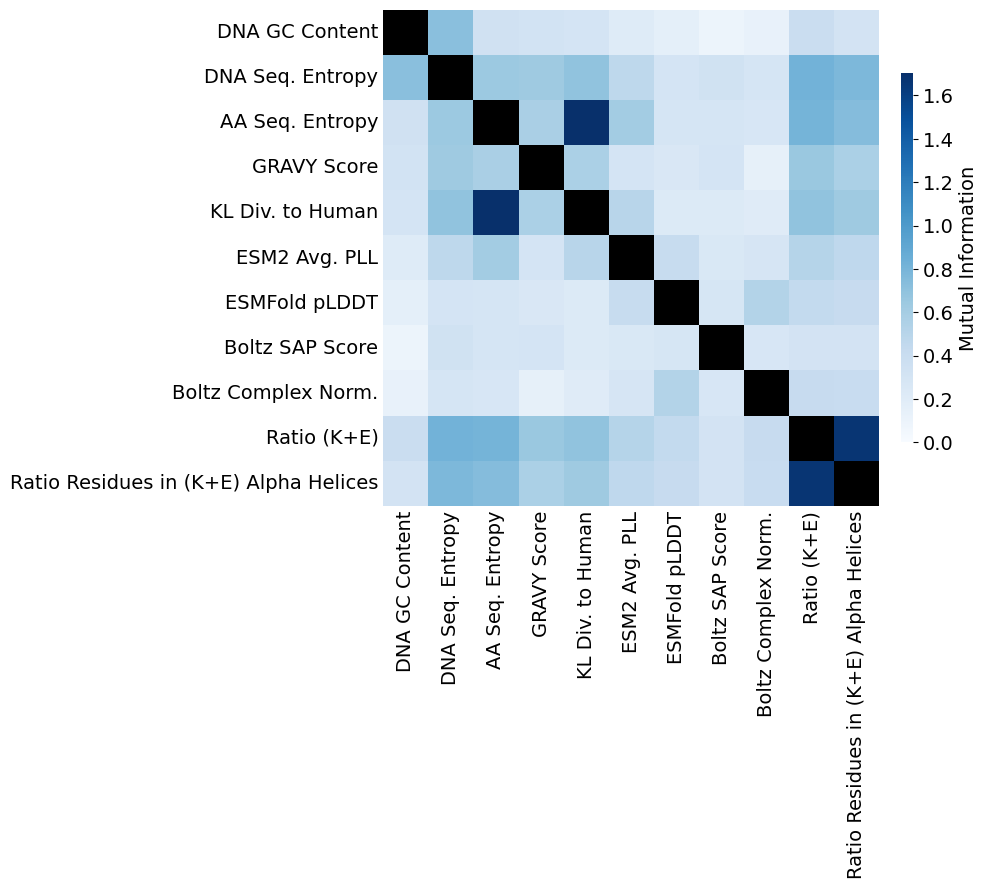

In [ ]:
# ----------------------------
# 1) choose columns
# ----------------------------

metric_cols = [
    "dna_gc_content",
    "dna_sequence_entropy",
    "aa_sequence_entropy",
    "gravy_score",
    "seq_kl_vs_human",
    "esm2_full_LL_alone",
    # "esm2_full_LL_target",
    "esmfold_plddt_binder_start_glycine_linker",
    "boltz_sap_score",
    "boltz_rosetta_A_BC_complex_normalized",
    # "ratio_KE",
    "dssp_ke_alpha_ratio",
]

metric_labels = [
    "DNA GC Content",
    "DNA Seq. Entropy",
    "AA Seq. Entropy",
    "GRAVY Score",
    "KL Div. to Human",
    "ESM2 Avg. PLL",
    # "ESM2 Average Pseudo Log Likelihood (Binder + Target)",
    "ESMFold pLDDT",# (Binder|Glycine Linker|Target)",
    "Boltz SAP Score",
    "Boltz Complex Norm.",
    # "Ratio (K+E)",
    "Ratio Residues in (K+E) Alpha Helices"
]

# build df with just metrics
df_metrics = metrics_df[metric_cols]

# ----------------------------
# 2) compute pairwise MI (all continuous)
# ----------------------------

mi_matrix = pd.DataFrame(index=metric_cols, columns=metric_cols, dtype=float)

for i, col_i in enumerate(metric_cols):
    for j, col_j in enumerate(metric_cols):
        if j < i:
            mi_matrix.loc[col_i, col_j] = mi_matrix.loc[col_j, col_i]
            continue

        s1 = df_metrics[col_i]
        s2 = df_metrics[col_j]

        # drop rows where either is nan
        mask = s1.notna() & s2.notna()
        x = s1[mask]
        y = s2[mask]

        if len(x) < 5:
            mi_val = np.nan
        elif col_i == col_j:
            # put something meaningful on the diagonal if you want
            # here we just set it to nan and will draw black manually
            mi_val = np.nan
        else:
            mi_val = mutual_info_regression(
                x.values.reshape(-1, 1),
                y.values,
                random_state=169873,
            )[0]

        mi_matrix.loc[col_i, col_j] = mi_val
        mi_matrix.loc[col_j, col_i] = mi_val

# ----------------------------
# 3) plot square heatmap
# ----------------------------

n = mi_matrix.shape[0]
fig_w = max(10, n * 0.18)
fig_h = max(10, n * 0.18)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

plot_matrix = mi_matrix.copy().astype(float)

# compute vmax from off diagonal entries only
vals = plot_matrix.values
off_diag = vals.copy()
np.fill_diagonal(off_diag, np.nan)
vmax = np.nanmax(off_diag[np.isfinite(off_diag)])

# do not color the diagonal via the colormap
np.fill_diagonal(plot_matrix.values, np.nan)

hm = sns.heatmap(
    plot_matrix,
    cmap="Blues",
    vmin=0,
    vmax=vmax,
    square=True,
    cbar_kws={
        "label": "Mutual Information",
        "shrink": 0.6,
        "fraction": 0.03,
        "pad": 0.04,
        "aspect": 30,
    },
    xticklabels=True,
    yticklabels=True,
    ax=ax,
)

# overlay black squares on the diagonal
for i in range(n):
    ax.add_patch(
        plt.Rectangle(
            (i, i), 1, 1,
            facecolor="black",
            edgecolor="black",
            linewidth=0,
            zorder=3,
        )
    )

# ticks and labels
ax.set_xticks(np.arange(n) + 0.5)
ax.set_yticks(np.arange(n) + 0.5)

ax.set_xticklabels(metric_labels, rotation=90, fontsize=14)
ax.set_yticklabels(metric_labels, rotation=0, fontsize=14)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

# make legend font bigger
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
# make cbar unit label bigger
cbar.ax.yaxis.label.set_size(14)

plt.tight_layout()
plt.savefig("../results/analysis/mi_heatmap_metrics_only.png", dpi=300, bbox_inches="tight")

# ==============================
# REMOVE THOSE WITHOUT DNA FOUND
# ==============================

In [10]:
# remove rows where twist dna not detected (results and metrics)
metrics_df = metrics_df.loc[results_df["leah_12k_twist_dna_detected"] == True].copy()
results_df = results_df.loc[results_df["leah_12k_twist_dna_detected"] == True].copy()
metrics_df = metrics_df.reset_index(drop=True)
results_df = results_df.reset_index(drop=True)

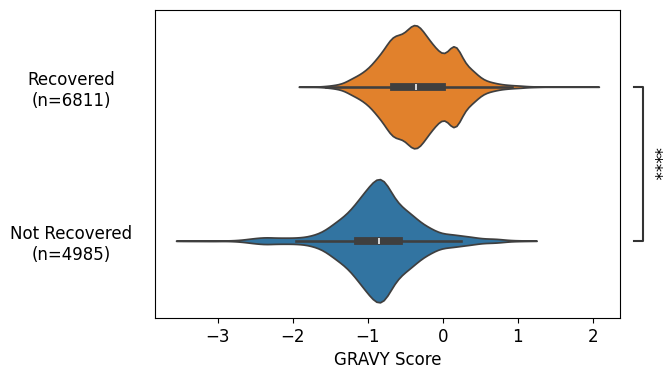

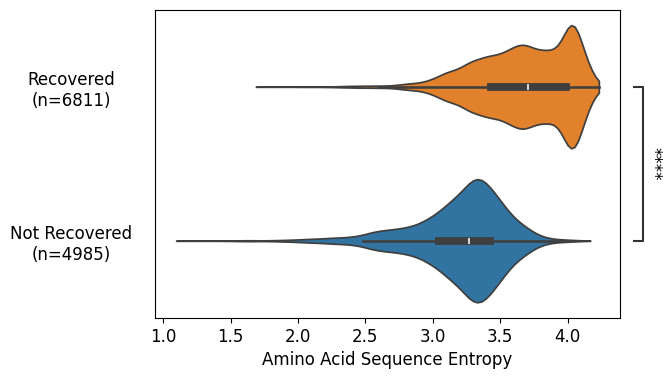

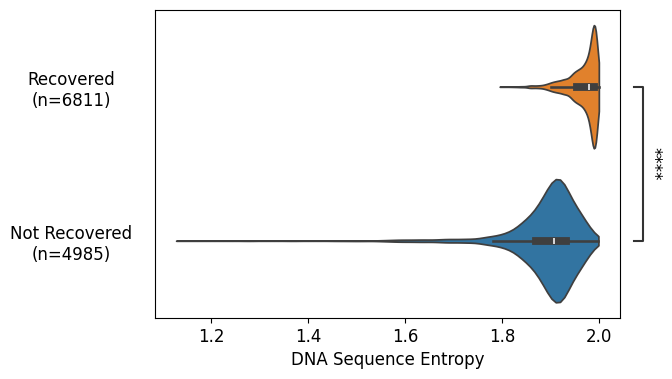

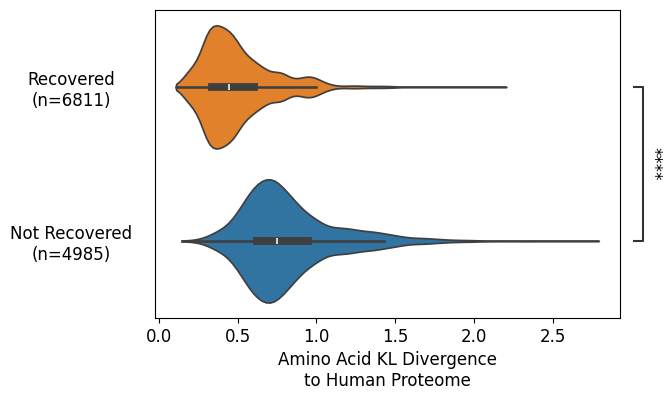

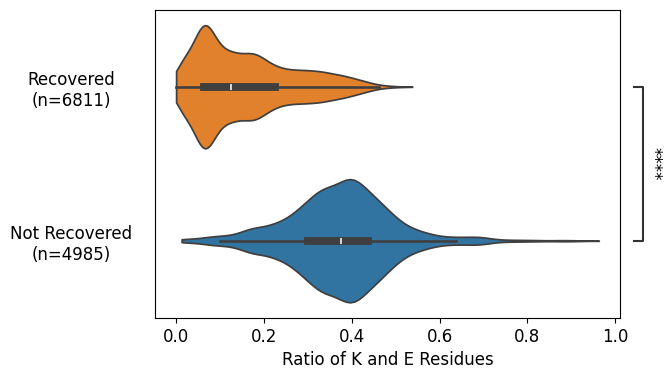

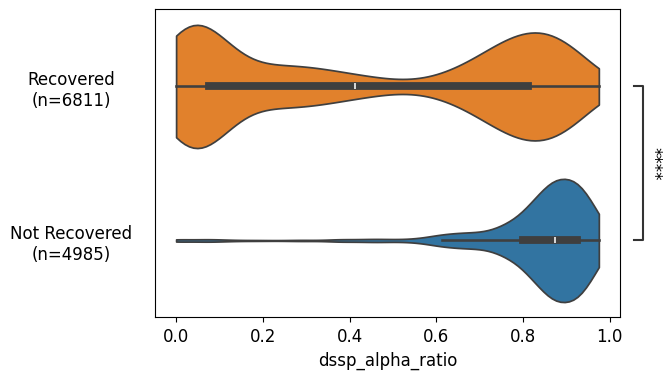

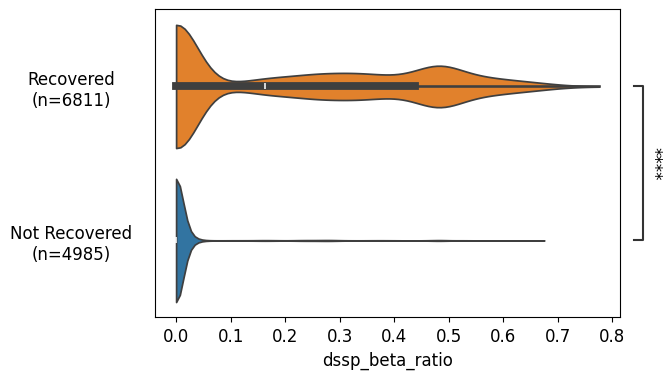

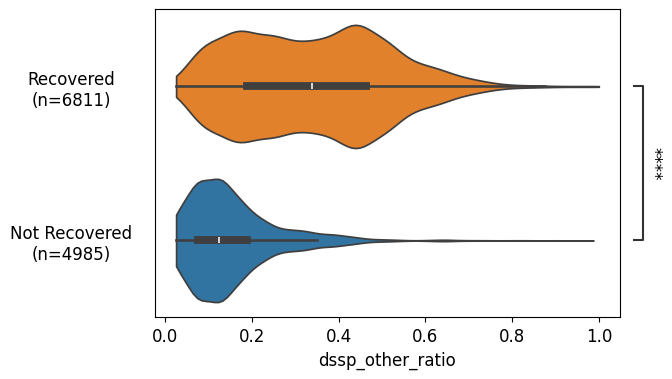

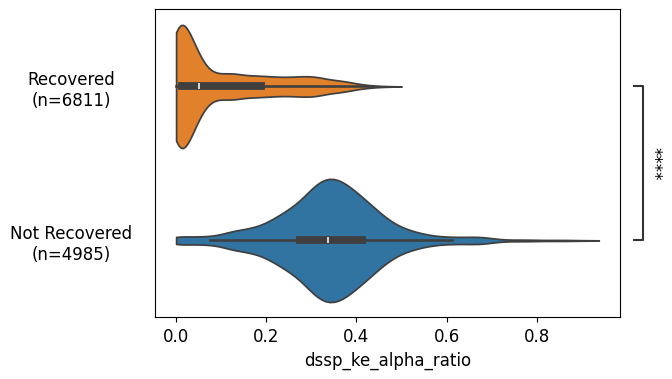

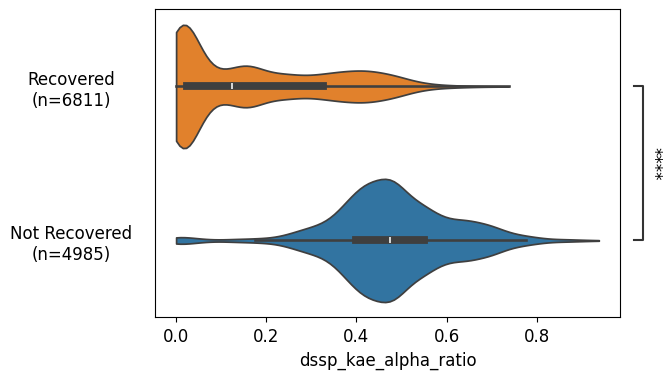

In [11]:
# make a simple violin plot: metrics vs leah_12k_detected

def plot_feature_violin_generic(
    feature,
    target_col,
    save_dir="../results/analysis",
    class_order=None,
    class_palette=None,
    feature_labels_map=None,
    y_labels_map=None,
):
    """
    Make a violin plot of a feature vs an arbitrary target column in results_df.

    Parameters
    ----------
    feature : str
        Column name in metrics_df.
    target_col : str
        Column name in results_df (binary or multiclass).
    save_dir : str
        Directory to save the figure.
    class_order : list, optional
        Explicit ordering of target classes. If None, uses value_counts order.
    class_palette : dict or list, optional
        Passed to seaborn as the palette; can be a mapping from class to color.
    feature_labels_map : dict, optional
        Mapping from feature name to prettier x label. If None, uses global
        feature_labels if available, otherwise uses the raw feature name.
    """
    # values for the feature
    feature_vals = metrics_df[feature].dropna()

    # align target on same index
    target_vals = results_df.loc[feature_vals.index, target_col]

    df = pd.DataFrame(
        {
            feature: feature_vals,
            "target": target_vals,
        },
        index=feature_vals.index,
    ).dropna(subset=[feature, "target"])

    # build class order
    if class_order is None:
        class_order = df["target"].value_counts().index.tolist()

    # normalize everything to string labels so seaborn + palette + y_labels_map agree
    df["target"] = df["target"].astype(str)
    class_order = [str(c) for c in class_order]

    if isinstance(class_palette, dict):
        class_palette = {str(k): v for k, v in class_palette.items()}

    if y_labels_map is not None:
        y_labels_map = {str(k): v for k, v in y_labels_map.items()}

    # make sure target is treated as categorical with the requested order
    df["target"] = pd.Categorical(df["target"], categories=class_order, ordered=True)

    # plotting
    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.violinplot(
        data=df,
        x=feature,
        y="target",
        orient="h",
        order=class_order,
        palette=class_palette,
        hue="target",
        ax=ax,
        cut=0,
        legend=False,
    )

    # counts for each class
    counts = (
        df["target"]
        .value_counts()
        .reindex(class_order)
        .fillna(0)
        .astype(int)
    )

    if y_labels_map is not None:
        new_labels = [
            y_labels_map.get(lab, lab) + f"\n(n={counts[lab]})"
            for lab in class_order
        ]
        ax.set_ylabel("")
    else:
        new_labels = [f"{lab}\n(n={counts[lab]})" for lab in class_order]
        ax.set_ylabel(target_col)

    ax.set_yticks(range(len(class_order)))
    ax.set_yticklabels(new_labels)

    ax.tick_params(axis="y", length=0)

    # x label
    if feature_labels_map is None and "feature_labels" in globals():
        feature_labels_map = feature_labels

    xlabel = (
        feature_labels_map.get(feature, feature)
        if feature_labels_map is not None
        else feature
    )
    ax.set_xlabel(xlabel)

    # center y tick labels and shift left (similar to your existing function)
    for label in ax.get_yticklabels():
        label.set_horizontalalignment("center")
        label.set_x(-0.17)

    # statannotations: all pairwise comparisons between classes in class_order
    pairs = []
    for i in range(len(class_order)):
        for j in range(i + 1, len(class_order)):
            pairs.append((class_order[i], class_order[j]))

    annotator = Annotator(
        ax,
        pairs,
        data=df,
        y="target",
        x=feature,
        order=class_order,
        orient="h",
    )
    annotator.configure(
        test="Mann-Whitney",
        text_format="star",
        loc="outside",
        verbose=0,
    )
    annotator.apply_and_annotate()

    feature_safe = feature.replace(" ", "_")
    target_safe = target_col.replace(" ", "_")
    out_path = f"{save_dir}/feature_{feature_safe}_by_{target_safe}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    # plt.close()


# binary target



for feature in ["gravy_score",
    "aa_sequence_entropy",
    "dna_sequence_entropy",
    "seq_kl_vs_human",
    "ratio_KE",
    # "max_charge_len_20",
    # "min_charge_len_20",
    # "longest_stretch_of_K",
    # "longest_stretch_of_E",
    # "longest_stretch_of_A",
    # "max_gravy_len_20",
    # "min_gravy_len_20",
    "dssp_alpha_ratio",
    "dssp_beta_ratio",
    "dssp_other_ratio",
    "dssp_ke_alpha_ratio",
    "dssp_kae_alpha_ratio",
    ]:
    plot_feature_violin_generic(
        feature=feature,
        target_col="leah_12k_detected",
        feature_labels_map={"aa_sequence_entropy": "Amino Acid Sequence Entropy", "gravy_score": "GRAVY Score", "dna_gc_content": "DNA GC Content", "dna_sequence_entropy": "DNA Sequence Entropy", "seq_kl_vs_human": "Amino Acid KL Divergence\nto Human Proteome", "ratio_KE": "Ratio of K and E Residues"},
        class_order=[True, False],
        # true orange false blue (original matplotlib colors)
        class_palette={True: "#ff7f0e", False: "#1f77b4"},
        y_labels_map={True: "Recovered", False: "Not Recovered"},
    )

# # multiclass target with custom order and palette
# my_order = ["class_A", "class_B", "class_C"]
# my_palette = {
#     "class_A": "#009E73",
#     "class_B": "#D55E00",
#     "class_C": "#0072B2",
# }
# plot_feature_violin_generic(
#     feature="aa_sequence_entropy",
#     target_col="my_multiclass_col",
#     class_order=my_order,
#     class_palette=my_palette,
# )

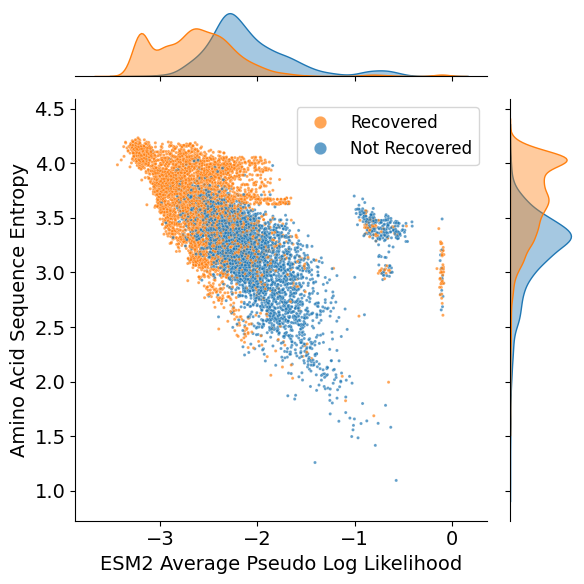

In [12]:

def pretty_label(name):
    return (
        name.replace("_", " ")
            .title()
            .replace("Ll", "Log Likelihood")
            .replace("Car", "CAR")
            .replace("Esm", "ESM")
            .replace("Bc", "BC")
            .replace("Gc", "GC")
            .replace("Dna", "DNA")
    )


def plot_joint_two_features(
    feat_x,
    feat_y,
    metrics_df,
    results_df,
    hue_col="fourclass",          # e.g. "fourclass" or "leah_12k_detected"
    hue_order=None,
    palette=None,
    out_path=None,
):
    # ensure fourclass exists if requested
    if hue_col == "fourclass":
        results_df = ensure_fourclass(results_df)

    # base plotting df
    # add any extras you care about here if needed
    plot_df = metrics_df[[feat_x, feat_y]].copy()
    plot_df = plot_df.dropna(subset=[feat_x, feat_y])
    

    # attach hue column from results_df
    if hue_col == "fourclass":
        h = results_df.loc[plot_df.index, "fourclass"]
        plot_df["hue"] = h
    elif hue_col == "leah_12k_detected":
        # map to nicer labels
        h_raw = results_df.loc[plot_df.index, "leah_12k_detected"].astype(bool)
        plot_df["hue"] = np.where(h_raw, "Recovered", "Not Recovered")
    else:
        # generic: directly copy that column
        h = results_df.loc[plot_df.index, hue_col]
        plot_df["hue"] = h

    # drop rows with missing hue
    plot_df = plot_df[plot_df["hue"].notna()]

    # default orders and palettes if not provided
    if hue_col == "fourclass":
        default_order = [
            "Not Recovered",
            "Not Sig",
            "Up",
            "Down",
        ]
        default_palette = {
            "Down": "#009E73",
            "Not Sig": "#D55E00",
            "Up": "#0072B2",
            "Not Detected": "#F0E442",
        }
        # sort to have nicer layering
        cat_order = {
            "Not Detected": 0,
            "Not Sig": 1,
            "Up": 2,
            "Down": 3,
        }
        plot_df = plot_df.assign(sort_key=plot_df["hue"].map(cat_order))
        plot_df = plot_df.sort_values("sort_key", ascending=True)
    elif hue_col == "leah_12k_detected":
        default_order = ["Recovered", "Not Recovered"]
        default_palette = {
            "Recovered": "#0072B2",
            "Not Recovered": "#D55E00",
        }
    else:
        # fall back to sorted unique values and let seaborn choose colors
        default_order = sorted(plot_df["hue"].unique())
        default_palette = None

    if hue_order is None:
        hue_order = default_order
    if palette is None:
        palette = default_palette

    # plot_df = plot_df.sort_values(by="hue", ascending=True)
    # rand order
    plot_df = plot_df.sample(frac=1, random_state=42)

    g = sns.jointplot(
        data=plot_df,
        x=feat_x,
        y=feat_y,
        hue="hue",
        hue_order=hue_order,
        palette=palette,
        kind="scatter",
        s=5,
        alpha=0.7,
        marginal_kws=dict(common_norm=False, fill=True, alpha=0.4),
    )

    # pretty axis labels
    # g.ax_joint.set_xlabel(pretty_label(feat_x), fontsize=14)
    g.ax_joint.set_xlabel("ESM2 Average Pseudo Log Likelihood", fontsize=14)
    g.ax_joint.set_ylabel("Amino Acid Sequence Entropy", fontsize=14)

    g.ax_joint.tick_params(axis="x", labelsize=14)
    g.ax_joint.tick_params(axis="y", labelsize=14)

    # legend with larger markers in the right order
    leg = g.ax_joint.get_legend()
    handles = leg.legend_handles
    g.ax_joint.legend(
        handles,
        hue_order,
        markerscale=4,
        fontsize=12,
        title="",
    )

    plt.tight_layout()

    if out_path is None:
        out_path = f"../results/analysis/joint_{feat_x}_{feat_y}_by_{hue_col}.png"

    plt.savefig(out_path, dpi=300)
    # plt.close(g.fig)

# color by binary leah_12k_detected (mapped to "Detected"/"Not Detected")
plot_joint_two_features(
    "esm2_full_LL_target",
    "aa_sequence_entropy",
    metrics_df,
    results_df,
    hue_col="leah_12k_detected",
    hue_order=["Recovered", "Not Recovered"],
    # palette={True: "#ff7f0e", False: "#1f77b4"},
    palette={"Recovered": "#ff7f0e", "Not Recovered": "#1f77b4"},
)

In [13]:
# far right cluster
# all schoeder lab w/ 3-4 linkers

mask = (
    (metrics_df["esm2_full_LL_target"] > -(30/80))
    # & (metrics_df["aa_sequence_entropy"] > 3.2)
)

print(metrics_df.loc[mask]["total_duplicated_residues"].value_counts())
# is linker
metrics_df.loc[mask][["global_id", "team", "sequence", "aa_sequence_entropy", "esm2_full_LL_target", "closest_ab", "ubiquitin_pident", "is_linker", "longest_dup_substr_len", "longest_dup_occurrences", "total_duplicated_residues", "longest_dup_substr"]].to_csv("../results/analysis/schoeder_cluster.csv", index=False)

# print # of hits
# results_df.loc[mask]["leah_12k_detected"]

total_duplicated_residues
60    21
66    18
72    11
63     5
64     2
80     2
76     1
Name: count, dtype: int64


In [14]:
# Zist Rayanesh cluster!
# has linkers

# esm2 > -150 and < 80
mask = (
    (metrics_df["esm2_full_LL_target"] > -(90/80))
    & (metrics_df["esm2_full_LL_target"] < -(30/80))
    & (metrics_df["aa_sequence_entropy"] > 3.2)
)

print(metrics_df.loc[mask]["total_duplicated_residues"].value_counts())
# is linker
metrics_df.loc[mask][["global_id", "team", "sequence", "aa_sequence_entropy", "esm2_full_LL_target", "closest_ab", "ubiquitin_pident", "is_linker", "longest_dup_substr_len", "longest_dup_occurrences", "total_duplicated_residues", "longest_dup_substr"]].to_csv("../results/analysis/zist_cluster.csv", index=False)

# print # of hits
# results_df.loc[mask]["leah_12k_detected"]

# find lowest gravy score when leah_12k_detected is True
# metrics_df.loc[results_df[results_df["leah_12k_detected"] == True].index]["gravy_score"].min()
# results_df.loc[metrics_df[metrics_df["dna_sequence_entropy"] < 1.85].index]["leah_12k_detected"].value_counts()
# results_df.loc[metrics_df[metrics_df["gravy_score"] < -1.919].index]["dna_sequence"]
# results_df.loc[metrics_df[metrics_df["aa_sequence_entropy"] < 2].index]["leah_12k_detected"].value_counts()

total_duplicated_residues
60    84
68    57
58    50
66    37
62    36
70     2
64     2
Name: count, dtype: int64


gravy_score: MI=0.151, Pearson r=0.473, p=0.00e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Down vs. Not Sig: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.450e-03 U_stat=4.215e+05
Not Sig vs. Up: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.638e-40 U_stat=2.737e+06
Up vs. Not Recovered: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.339e-73 U_stat=2.504e+06
aa_sequence_entropy: MI=0.226, Pearson r=0.548, p=0.00e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Down vs. Not Sig: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.901e-28 U_stat=7.383e+05
Not Sig 

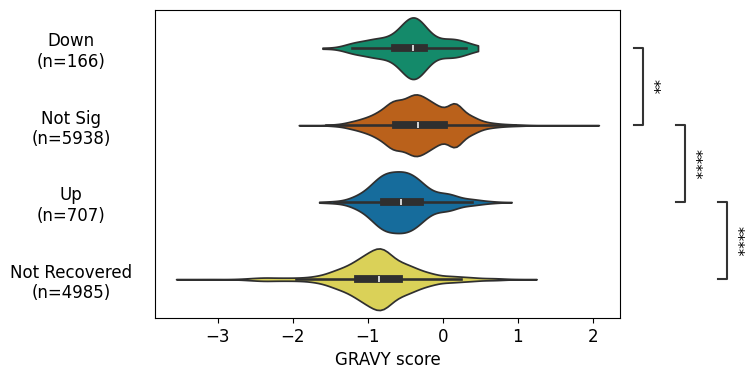

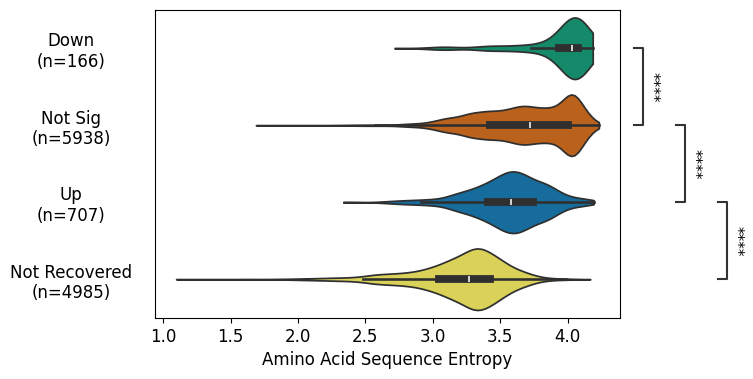

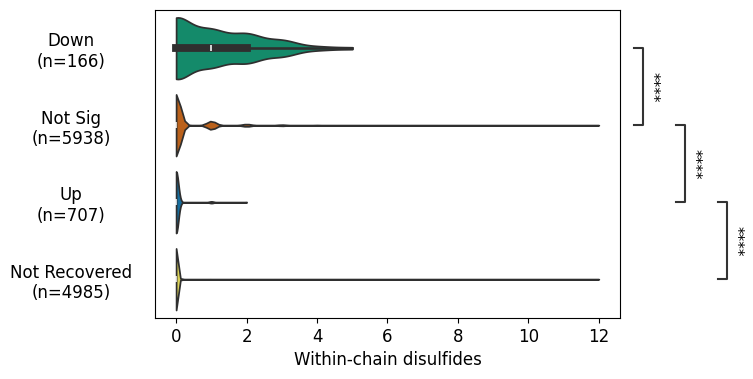

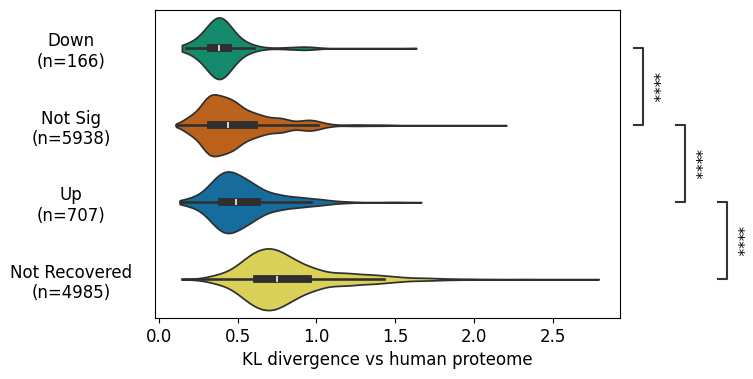

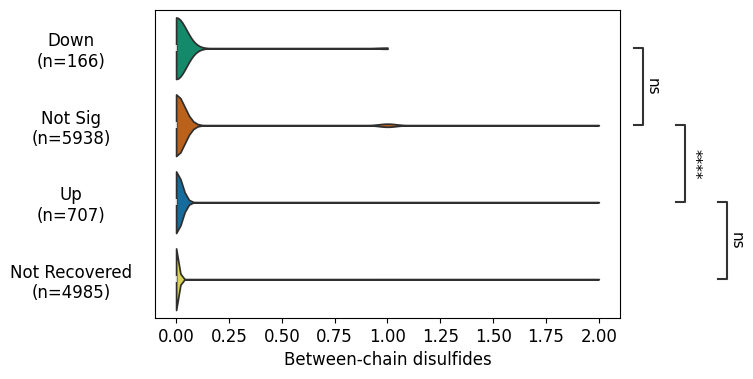

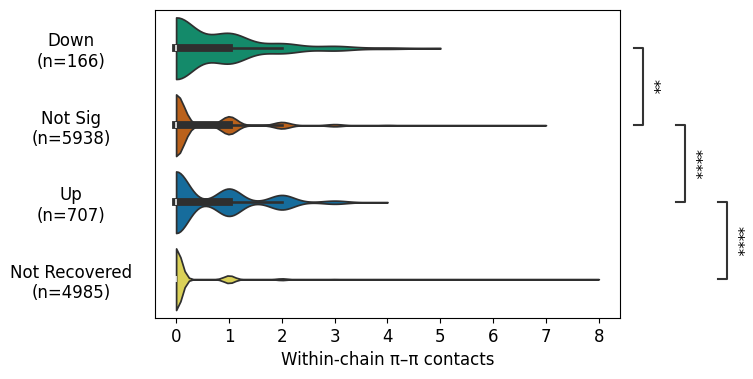

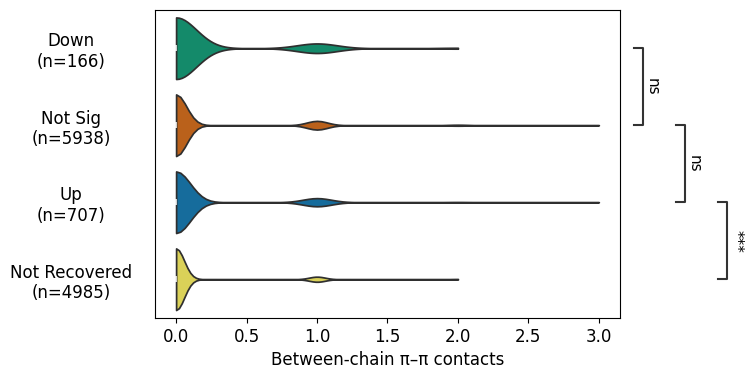

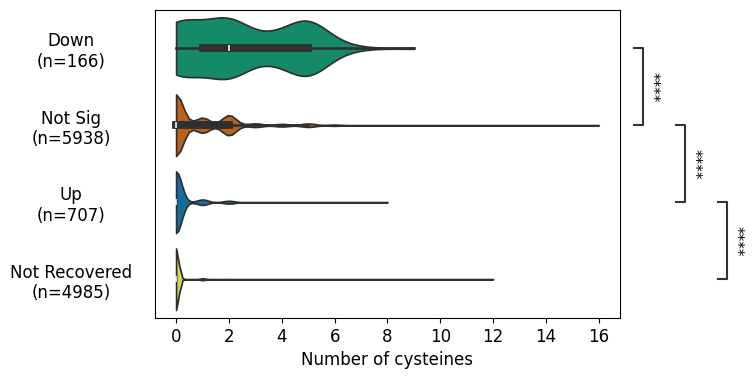

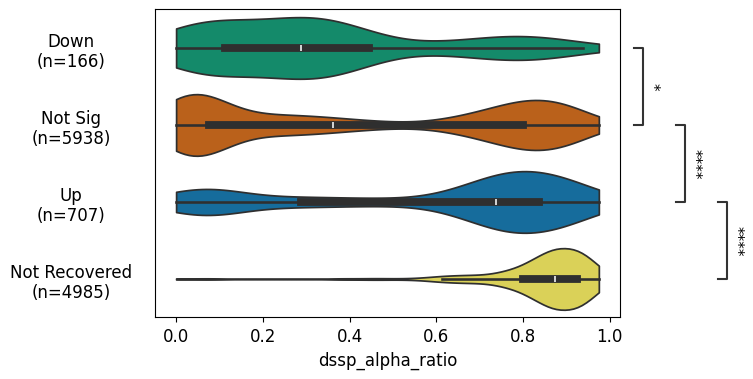

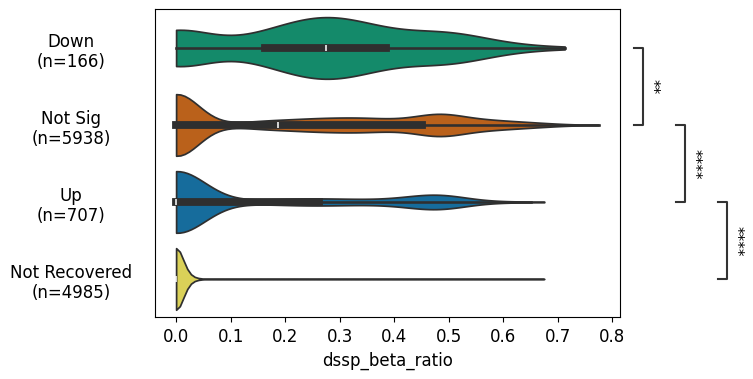

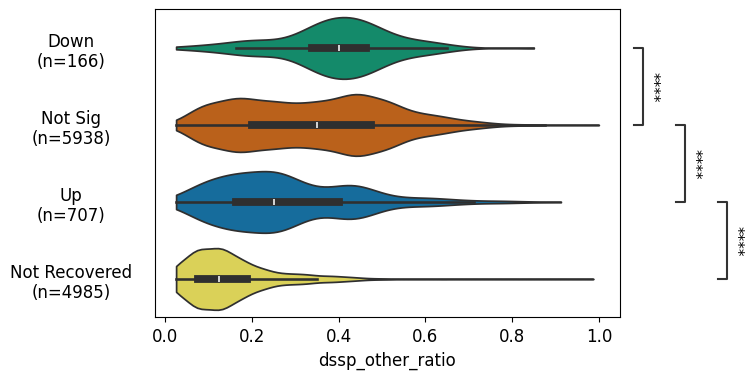

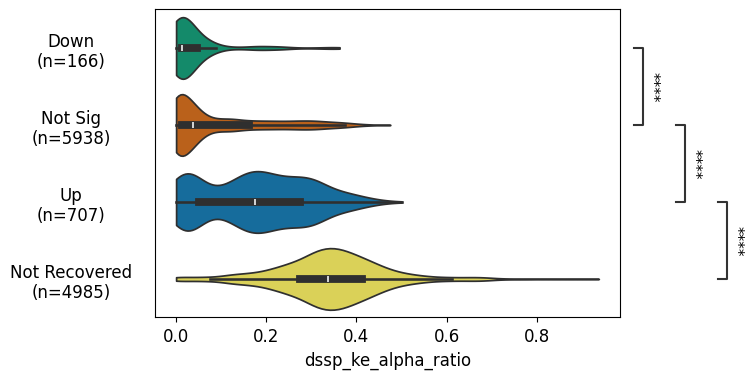

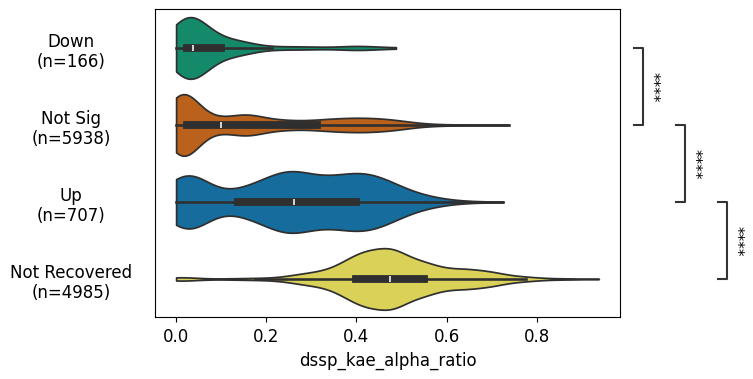

In [15]:
# ---------- shared setup ----------

y_metric = "fourclass"

def map_four_class(v):
    if pd.isna(v):
        return "Not Recovered"
    if v == -1:
        return "Down"
    if v == 0:
        return "Not Sig"
    if v == 1:
        return "Up"
    return "Not Recovered"

order = [
    "Down",
    "Not Sig",
    "Up",
    "Not Recovered",
]

# optional prettier x labels
feature_labels = {
    "gravy_score": "GRAVY score",
    "aa_sequence_entropy": "Amino Acid Sequence Entropy",
    "num_cysteines": "Number of cysteines",
    "num_disulfide_within_chain": "Within-chain disulfides",
    "num_disulfide_between_chain": "Between-chain disulfides",
    "num_pipi_within_chain": "Within-chain π–π contacts",
    "num_pipi_between_chain": "Between-chain π–π contacts",
    "seq_kl_vs_human": "KL divergence vs human proteome",
    "seq_charge": "Net Charge at pH 7.0",
}

# ids to highlight on the "Up" row
highlight_ids = {1506, 5300, 5981, 3718, 2383, 3494}

# ---------- helper to build per feature df ----------

def build_feature_df(feature):
    # values for that feature
    feature_vals = metrics_df[feature].dropna()

    # align targets on same index
    detected = results_df.loc[feature_vals.index, "leah_12k_detected"]
    threeclass = results_df.loc[feature_vals.index, "leah_12k_2fold_threshold_int"]

    df = pd.DataFrame(
        {
            feature: feature_vals,
            "detected": detected,
        },
        index=feature_vals.index,
    ).dropna(subset=[feature, "detected"])

    df["threeclass"] = threeclass.loc[df.index]
    df["global_id"] = results_df.loc[df.index, "global_id"]
    df["fourclass"] = df["threeclass"].apply(map_four_class)

    return df

# ---------- plotting function for one feature ----------

def plot_feature_violin(feature, save_dir="../results/analysis"):
    df = build_feature_df(feature)

    # MI and Pearson vs detected
    X = df[feature].values.reshape(-1, 1)
    y = df["detected"].values

    mi_val = mutual_info_classif(
        X,
        y,
        random_state=169873,
    )[0]

    pearson_corr, pearson_pval = pearsonr(df[feature].values, y)

    print(
        f"{feature}: MI={mi_val:.3f}, "
        f"Pearson r={pearson_corr:.3f}, p={pearson_pval:.2e}"
    )

    # plotting
    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.violinplot(
        data=df,
        x=feature,
        y="fourclass",
        orient="h",
        order=order,
        palette=palette,
        hue="fourclass",
        ax=ax,
        cut=0,
    )

    # restrict counts and stats to actually plotted data
    valid = df["fourclass"].notna() & df[feature].notna()
    dplot = df.loc[valid]

    counts = (
        dplot["fourclass"]
        .value_counts()
        .reindex(order)
        .fillna(0)
        .astype(int)
    )

    new_labels = [f"{lab}\n(n={counts[lab]})" for lab in order]
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(new_labels)

    ax.tick_params(axis="y", length=0)
    ax.set_ylabel("")

    xlabel = feature_labels.get(feature, feature)
    ax.set_xlabel(xlabel)

    # center y tick labels and shift left
    for label in ax.get_yticklabels():
        label.set_horizontalalignment("center")
        label.set_x(-0.17)

    # # highlight ids on the "Up" row
    # if highlight_ids:
    #     mask_highlight = (
    #         (df["fourclass"] == "Up")
    #         & df["global_id"].isin(highlight_ids)
    #         & df[feature].notna()
    #     )

    #     x_high = df.loc[mask_highlight, feature].values
    #     y_pos = order.index("Up")

    #     ax.scatter(
    #         x_high,
    #         np.full_like(x_high, y_pos, dtype=float),
    #         marker="x",
    #         s=70,
    #         color="#39FF14",
    #         edgecolor="black",
    #         linewidth=0.4,
    #         zorder=10,
    #     )

    # statannotations
    pairs = [
        ("Down", "Not Sig"),
        ("Not Sig", "Up"),
        ("Up", "Not Recovered"),
        # ("Down", "Up"),
        # ("Down", "Not Recovered"),
        # ("Not Sig", "Not Recovered"),
    ]

    annotator = Annotator(
        ax,
        pairs,
        data=dplot,
        x=feature,
        y="fourclass",
        order=order,
        orient="h",
    )
    annotator.configure(
        test="Mann-Whitney",
        comparisons_correction="BH",
        text_format="star",
        pvalue_thresholds=[
            (1e-4, "****"),
            (1e-3, "***"),
            (1e-2, "**"),
            (0.05, "*"),
            (1, "ns"),
        ],
        show_test_name=False,
        loc="outside",
        fontsize=11,
        hide_non_significant=False,
    )
    annotator.apply_and_annotate()

    feature_safe = feature.replace(" ", "_")
    out_path = f"{save_dir}/feature_{feature_safe}_by_4class_detected.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    # plt.close()

# ---------- run for all metrics ----------

metrics_list = [
    "gravy_score",
    "aa_sequence_entropy",
    "num_disulfide_within_chain",
    "seq_kl_vs_human",
    "num_disulfide_between_chain",
    "num_pipi_within_chain",
    "num_pipi_between_chain",
    "num_cysteines",
    # "seq_charge",
    "dssp_alpha_ratio",
    "dssp_beta_ratio",
    "dssp_other_ratio",
    "dssp_ke_alpha_ratio",
    "dssp_kae_alpha_ratio",
]

for feature in metrics_list:
    plot_feature_violin(feature)

gravy_score: MI=0.151, Pearson r=0.473, p=0.00e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Down vs. Not Sig: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.450e-03 U_stat=4.215e+05
Not Sig vs. Up: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.638e-40 U_stat=2.737e+06
Up vs. Not Recovered: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.339e-73 U_stat=2.504e+06
aa_sequence_entropy: MI=0.226, Pearson r=0.548, p=0.00e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Down vs. Not Sig: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.901e-28 U_stat=7.383e+05
Not Sig 

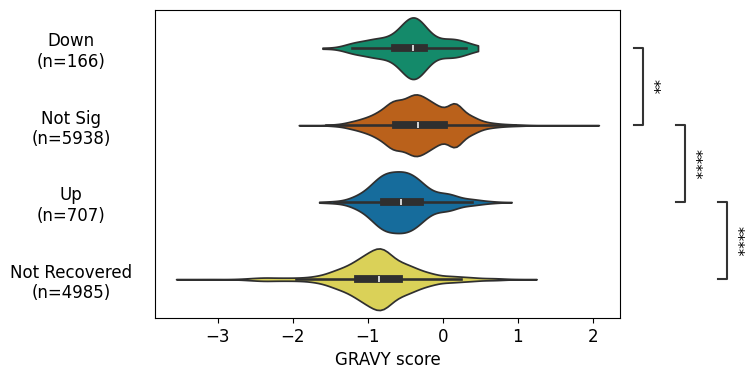

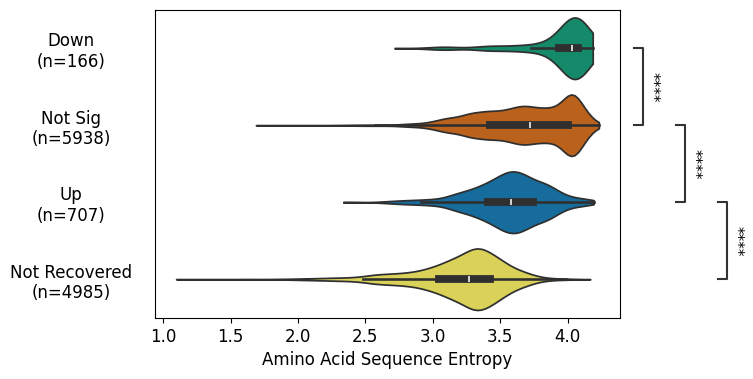

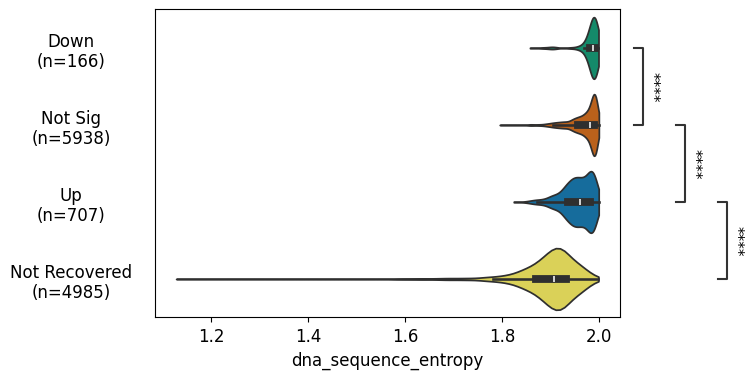

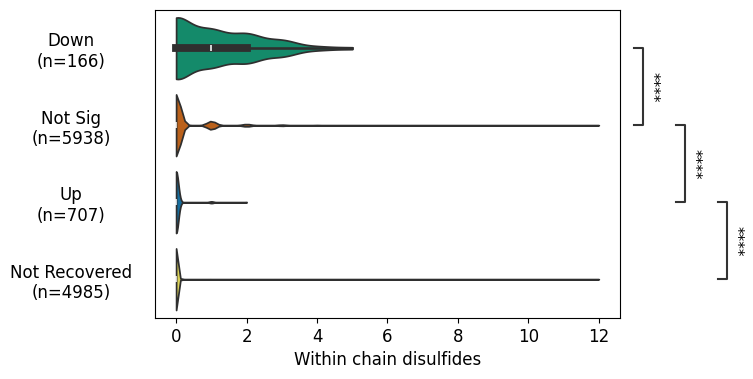

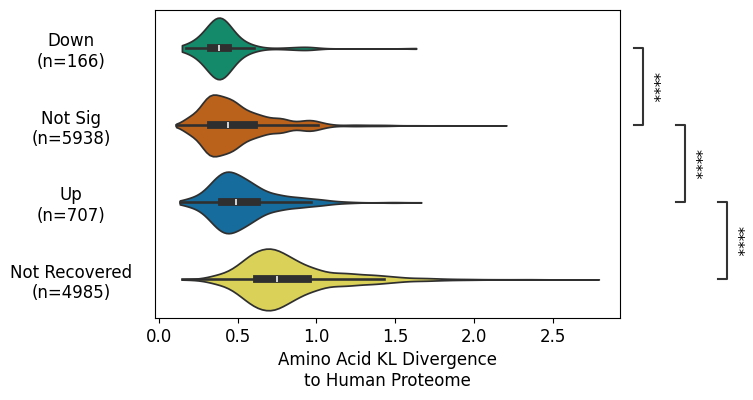

In [16]:
# ---------- shared setup ----------


# integer up/down/not sig mapping
results_df["leah_12k_2fold_threshold_int"] = results_df["leah_12k_2fold_threshold"].map(
    {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
)

def map_four_class(v):
    if pd.isna(v):
        return "Not Recovered"
    if v == -1:
        return "Down"
    if v == 0:
        return "Not Sig"
    if v == 1:
        return "Up"
    return "Not Recovered"

order = [
    "Down",
    "Not Sig",
    "Up",
    "Not Recovered",
]

# optional prettier x labels
feature_labels = {
    "gravy_score": "GRAVY score",
    "aa_sequence_entropy": "Amino Acid Sequence Entropy",
    "num_cysteines": "Number of cysteines",
    "num_disulfide_within_chain": "Within chain disulfides",
    "num_disulfide_between_chain": "Between chain disulfides",
    "num_pipi_within_chain": "Within chain π–π contacts",
    "num_pipi_between_chain": "Between chain π–π contacts",
    "seq_kl_vs_human": "Amino Acid KL Divergence\nto Human Proteome",
    "seq_charge": "Net Charge at pH 7.0",
}

# ids to highlight on the "Up" row
highlight_ids = {1506, 5300, 5981, 3718, 2383, 3494}

# ---------- helper to build per feature df ----------

def build_feature_df(feature):
    # values for that feature
    feature_vals = metrics_df[feature].dropna()

    # align targets on same index
    detected = results_df.loc[feature_vals.index, "leah_12k_detected"]
    threeclass = results_df.loc[feature_vals.index, "leah_12k_2fold_threshold_int"]

    df = pd.DataFrame(
        {
            feature: feature_vals,
            "detected": detected,
        },
        index=feature_vals.index,
    ).dropna(subset=[feature, "detected"])

    df["threeclass"] = threeclass.loc[df.index]
    df["global_id"] = results_df.loc[df.index, "global_id"]
    df["fourclass"] = df["threeclass"].apply(map_four_class)

    return df

# ---------- plotting function for one feature ----------

def plot_feature_violin(feature, save_dir="../results/analysis"):
    df = build_feature_df(feature)

    # MI and Pearson vs detected
    X = df[feature].values.reshape(-1, 1)
    y = df["detected"].values

    mi_val = mutual_info_classif(
        X,
        y,
        random_state=169873,
    )[0]

    pearson_corr, pearson_pval = pearsonr(df[feature].values, y)

    print(
        f"{feature}: MI={mi_val:.3f}, "
        f"Pearson r={pearson_corr:.3f}, p={pearson_pval:.2e}"
    )

    # plotting
    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.violinplot(
        data=df,
        x=feature,
        y="fourclass",
        orient="h",
        order=order,
        palette=palette,
        hue="fourclass",
        ax=ax,
        cut=0,
    )

    # restrict counts and stats to actually plotted data
    valid = df["fourclass"].notna() & df[feature].notna()
    dplot = df.loc[valid]

    counts = (
        dplot["fourclass"]
        .value_counts()
        .reindex(order)
        .fillna(0)
        .astype(int)
    )

    new_labels = [f"{lab}\n(n={counts[lab]})" for lab in order]
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(new_labels)

    ax.tick_params(axis="y", length=0)
    ax.set_ylabel("")

    xlabel = feature_labels.get(feature, feature)
    ax.set_xlabel(xlabel)

    # center y tick labels and shift left
    for label in ax.get_yticklabels():
        label.set_horizontalalignment("center")
        label.set_x(-0.17)

    # # highlight ids on the "Up" row
    # if highlight_ids:
    #     mask_highlight = (
    #         (df["fourclass"] == "Up")
    #         & df["global_id"].isin(highlight_ids)
    #         & df[feature].notna()
    #     )

    #     x_high = df.loc[mask_highlight, feature].values
    #     y_pos = order.index("Up")

    #     ax.scatter(
    #         x_high,
    #         np.full_like(x_high, y_pos, dtype=float),
    #         marker="x",
    #         s=70,
    #         color="#39FF14",
    #         edgecolor="black",
    #         linewidth=0.4,
    #         zorder=10,
    #     )

    # statannotations
    pairs = [
        ("Down", "Not Sig"),
        ("Not Sig", "Up"),
        ("Up", "Not Recovered"),
    ]

    annotator = Annotator(
        ax,
        pairs,
        data=dplot,
        x=feature,
        y="fourclass",
        order=order,
        orient="h",
    )
    annotator.configure(
        test="Mann-Whitney",
        comparisons_correction="BH",
        text_format="star",
        pvalue_thresholds=[
            (1e-4, "****"),
            (1e-3, "***"),
            (1e-2, "**"),
            (0.05, "*"),
            (1, "ns"),
        ],
        show_test_name=False,
        loc="outside",
        fontsize=11,
        hide_non_significant=False,
    )
    annotator.apply_and_annotate()

    feature_safe = feature.replace(" ", "_")
    out_path = f"{save_dir}/feature_{feature_safe}_by_4class_detected.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    # plt.close()

# ---------- run for all metrics ----------

metrics_list = [
    "gravy_score",
    "aa_sequence_entropy",
    "dna_sequence_entropy",
    # "num_cysteines",
    "num_disulfide_within_chain",
    # "num_disulfide_between_chain",
    # "num_pipi_within_chain",
    # "num_pipi_between_chain",
    "seq_kl_vs_human",
    # "seq_charge",
]

for feature in metrics_list:
    plot_feature_violin(feature)

In [17]:
# # remove sequences with:
# # KL > 0.7
# # >2 disulfides within chain
# # <3.3  and >3.8 seq complexity
# # <-1 and >1 gravy

# filtered_df = metrics_df[
#     (metrics_df["seq_kl_vs_human"] <= 0.6)
#     & (metrics_df["aa_sequence_entropy"] > 3.4)
#     & (metrics_df["aa_sequence_entropy"] <= 3.6)
#     # & (metrics_df["num_disulfide_within_chain"] < 2)
#     # & (metrics_df["gravy_score"] >= -1)
#     # & (metrics_df["gravy_score"] <= 1)
# ]

# # merge with results to see how many pass/fail
# filtered_results_df = results_df.loc[filtered_df.index]

# # describe categories
# # check 4class
# fourclass_counts = (
#     filtered_results_df["leah_12k_2fold_threshold_int"]
#     .apply(map_four_class)
#     .value_counts()
# )
# print("Filtered 4-class counts:")
# print(fourclass_counts)
# # print up hit ate
# up_hits = (
#     filtered_results_df["leah_12k_2fold_threshold_int"] == 1
# ).sum()
# total_detected = (
#     filtered_results_df["leah_12k_detected"] == True
# ).sum()
# up_hit_rate = up_hits / total_detected
# print(f"Up hits: {up_hits} / {total_detected} = {up_hit_rate:.3f}")

# # print default hit rate
# total_up_hits = (
#     results_df["leah_12k_2fold_threshold_int"] == 1
# ).sum()
# total_detected_all = (
#     results_df["leah_12k_detected"] == True
# ).sum()
# default_up_hit_rate = total_up_hits / total_detected_all
# print(f"Default Up hits: {total_up_hits} / {total_detected_all} = {default_up_hit_rate:.3f}")


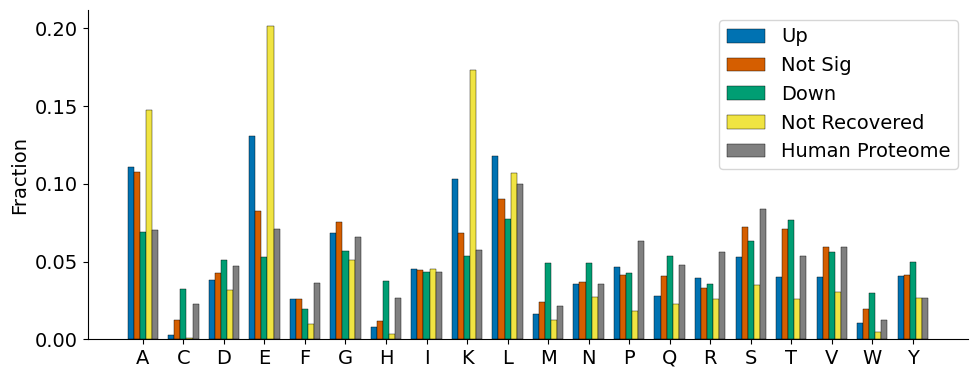

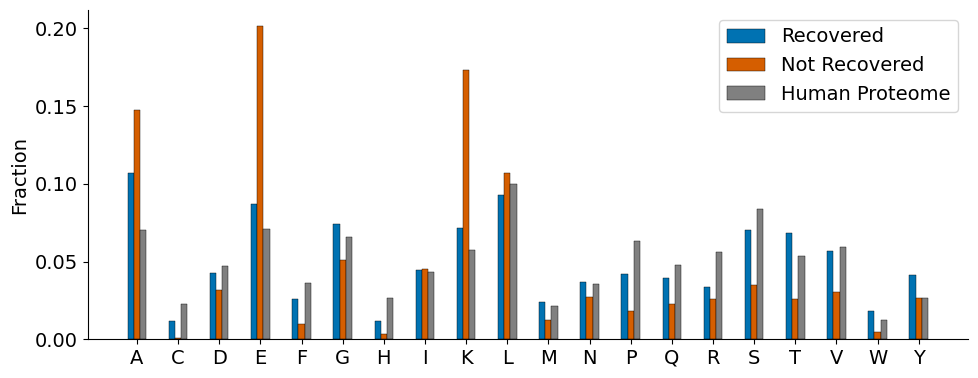

In [18]:
aa_order = list("ACDEFGHIKLMNPQRSTVWY")

def plot_aa_composition_by_group(
    df,
    group_col,
    group_order,
    palette,
    human_freqs,
    out_path,
):
    # need group and sequence
    valid = df[group_col].notna() & df["sequence"].notna()
    dplot = df.loc[valid].copy()

    group_comps = {}  # group -> list of freq per aa in aa_order

    for group, sub in dplot.groupby(group_col):
        counts = Counter()
        total_len = 0

        for seq in sub["sequence"]:
            s = str(seq).replace("*", "").upper()
            counts.update(s)
            total_len += len(s)

        if total_len == 0:
            freqs = [0.0] * len(aa_order)
        else:
            freqs = [counts[aa] / total_len for aa in aa_order]

        group_comps[group] = freqs

    # ----------------- grouped barplot with human frequencies -----------------
    plt.rcParams.update({"font.size": 14})
    fig, ax = plt.subplots(figsize=(10, 4))

    x = np.arange(len(aa_order))

    n_groups = len(group_order)
    n_barsets = n_groups + 1  # groups + human
    width = 0.15
    total_width = n_barsets * width
    start_offset = -total_width / 2.0 + width / 2.0

    # plot groups in the requested order
    for i, group in enumerate(group_order):
        freqs = group_comps.get(group, [0.0] * len(aa_order))
        offset = start_offset + i * width
        ax.bar(
            x + offset,
            freqs,
            width=width,
            label=str(group),
            color=palette.get(group, None),
            edgecolor="black",
            linewidth=0.3,
        )

    # human frequencies as last bar set
    human_freq_list = [human_freqs[aa] for aa in aa_order]
    human_offset = start_offset + n_groups * width

    ax.bar(
        x + human_offset,
        human_freq_list,
        width=width,
        label="Human Proteome",
        color="gray",
        edgecolor="black",
        linewidth=0.3,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(aa_order)
    ax.set_ylabel("Fraction")

    ax.legend(loc="upper right")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    # plt.close(fig)

fourclass_order = [
    "Up",
    "Not Sig",
    "Down",
    "Not Recovered",
]

def map_four_class_int_to_label(v):
    if pd.isna(v):
        return "Not Recovered"
    if v == 0:
        return "Not Sig"
    if v == 1:
        return "Up"
    if v == -1:
        return "Down"
    return "Not Recovered"


def ensure_fourclass(results_df):
    if "leah_12k_2fold_threshold_int" not in results_df.columns:
        results_df["leah_12k_2fold_threshold_int"] = results_df["leah_12k_2fold_threshold"].map(
            {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
        )
    if "fourclass" not in results_df.columns:
        results_df["fourclass"] = results_df["leah_12k_2fold_threshold_int"].apply(
            map_four_class_int_to_label
        )
    return results_df

fourclass_palette = palette  # your existing dict

results_df = ensure_fourclass(results_df)

plot_aa_composition_by_group(
    df=results_df,
    group_col="fourclass",
    group_order=fourclass_order,
    palette=fourclass_palette,
    human_freqs=human_freqs,
    out_path="../results/analysis/aa_composition_by_fourclass_with_human.png",
)


# make a readable two class column
results_df["detected_group"] = np.where(
    results_df["leah_12k_detected"].astype(bool),
    "Recovered",
    "Not Recovered",
)

detected_order = ["Recovered", "Not Recovered"]

detected_palette = {
    "Recovered": "#0072B2",
    "Not Recovered": "#D55E00",
}

plot_aa_composition_by_group(
    df=results_df,
    group_col="detected_group",
    group_order=detected_order,
    palette=detected_palette,
    human_freqs=human_freqs,
    out_path="../results/analysis/aa_composition_by_detected_with_human.png",
)

In [19]:
# # results_df[~results_df["leah_12k_detected"]][["leah_12k_N6_1", "leah_12k_N6_2", "leah_12k_N6_3", "leah_12k_R6_1", "leah_12k_R6_2", "leah_12k_R6_3"]].describe()
# combined_df = metrics_df.merge(results_df, on=["global_id", "sequence"])

# # combined_df[combined_df["esm2_full_LL_target"] > -150]["leah_12k_detected"].value_counts()
# combined_df["leah_12k_2fold_threshold"] = combined_df["leah_12k_2fold_threshold"].fillna("NaN")
# combined_df[combined_df["esm2_full_LL_target"] > -150]["leah_12k_2fold_threshold"].value_counts()

# def contains_linker(seq):
#     return "GGGS" in seq or "SSGSG" in seq or "GSGSG" in seq

# def contains_repeat(seq):
#     "contains a stretch of 4 characters in a row"
#     for i in range(len(seq) - 3):
#         if seq[i] == seq[i+1] == seq[i+2] == seq[i+3]:
#             return True
#     return False

# combined_df["contains_linker"] = combined_df["sequence"].apply(contains_linker)
# combined_df["contains_repeat"] = combined_df["sequence"].apply(contains_repeat)


# # print gravy by group
# gravy_stats = combined_df.groupby("leah_12k_2fold_threshold")["gravy"].describe()
# print("GRAVY stats by leah_12k_2fold_threshold:")
# print(gravy_stats)
# print()

# removed_df = pd.DataFrame()

# # combined_df[combined_df["esm2_full_LL_target"] > -150][["global_id", "sequence", "esm2_full_LL_target", "leah_12k_detected", "leah_12k_2fold_threshold", "msa_depth", "closest_ab", "contains_linker"]].sort_values(by=["leah_12k_2fold_threshold", "esm2_full_LL_target"]).to_csv("_tmp_goodesm.csv", index=False)

# print("Initial:")
# print(f"Total seqs: {len(combined_df)}")
# print(combined_df["leah_12k_2fold_threshold"].value_counts())
# print()

# print("ESM2 LL > -150:")
# combined_df = combined_df[combined_df["esm2_full_LL_target"] > -150].reset_index(drop=True)
# print(f"Total seqs: {len(combined_df)}")
# print(combined_df["leah_12k_2fold_threshold"].value_counts())
# print()

# print("mean boltz_rosetta_A_BC_complex_normalized")
# print(combined_df["boltz_rosetta_A_BC_complex_normalized"].describe())

# print("Removing seqs with GGGS, SSGSG, GSGSG linkers:")
# removed_df = pd.concat([removed_df, combined_df[combined_df["contains_linker"]]])
# combined_df = combined_df[~combined_df["contains_linker"]].reset_index(drop=True)
# print(f"Total seqs: {len(combined_df)}")
# print(combined_df["leah_12k_2fold_threshold"].value_counts())
# print()

# print("Removing seqs with any ab homology:")
# removed_df = pd.concat([removed_df, combined_df[combined_df["closest_ab_pident"] > 0]])
# combined_df = combined_df[combined_df["closest_ab_pident"] == 0].reset_index(drop=True)
# print(f"Total seqs: {len(combined_df)}")
# print(combined_df["leah_12k_2fold_threshold"].value_counts())
# print()

# print("Removing seqs with stretch of 4+ same character in a row:")
# removed_df = pd.concat([removed_df, combined_df[combined_df["contains_repeat"]]])
# combined_df = combined_df[~combined_df["contains_repeat"]].reset_index(drop=True)
# print(f"Total seqs: {len(combined_df)}")
# print(combined_df["leah_12k_2fold_threshold"].value_counts())
# print()


# combined_df[["global_id", "sequence", "esm2_full_LL_target", "boltz_rosetta_A_BC_complex_normalized", "leah_12k_detected", "leah_12k_2fold_threshold", "msa_depth",]].sort_values(by=["leah_12k_2fold_threshold", "esm2_full_LL_target"]).to_csv("_tmp_goodesm.csv", index=False)
# removed_df[["global_id", "sequence", "esm2_full_LL_target", "boltz_rosetta_A_BC_complex_normalized", "leah_12k_detected", "leah_12k_2fold_threshold", "msa_depth", "closest_ab_pident", "contains_linker", "contains_repeat"]].sort_values(by=["leah_12k_2fold_threshold", "esm2_full_LL_target"]).to_csv("_tmp_removed.csv", index=False)

In [20]:
# results_df_filtered = results_df[results_df["leah_12k_detected"]].reset_index(drop=True)
# results_df_filtered["leah_12k_2fold_threshold_int"] = results_df_filtered["leah_12k_2fold_threshold"].map({"Up": 1, "Not Sig": 0, "Down": -1})
# metrics_df_filtered = metrics_df[metrics_df["global_id"].isin(results_df_filtered["global_id"])].reset_index(drop=True)
# cols = metrics_df_filtered.columns.drop(["team", "global_id", "sequence", "closest_ab"]).tolist()

# mi_df = pd.DataFrame()
# for col in cols:
#     pre_len = len(metrics_df_filtered)
#     metrics_df_col = metrics_df_filtered[[col]].copy()
#     metrics_df_col = metrics_df_col[~metrics_df_col[col].isna()]
#     post_len = len(metrics_df_col)
#     X = metrics_df_col[col].values.reshape(-1, 1)
#     y = results_df_filtered.loc[metrics_df_col.index, "leah_12k_2fold_threshold_int"].values
#     mi = mutual_info_classif(
#         X,
#         y,
#         random_state=891237,
#         # n_neighbors=5,
#         # discrete_features=False,
#     )
#     sub_df = pd.DataFrame({
#         "metric": col,
#         "mi_vs_leah_12k_2fold_threshold_int": mi,
#         "num_non_nan": post_len,
#         "num_nan": pre_len - post_len,
#     })
#     mi_df = pd.concat([mi_df, sub_df], axis=0)
# mi_df = mi_df.sort_values("mi_vs_leah_12k_2fold_threshold_int", ascending=False).reset_index(drop=True)
# mi_df.to_csv("../results/analysis/feature_mi_vs_leah_12k_2fold_threshold_int_filtered.csv", index=False)

In [21]:
# # make a new metrics df that averages across each "team"
# # remember, we need to get rid of our non-float cols
# metrics_df_grouped = metrics_df.copy().drop(columns=["global_id", "sequence", "closest_ab"])
# metrics_df_grouped = metrics_df_grouped.dropna()
# print(f"Dropped to {len(metrics_df_grouped)} rows after dropping NA")
# metrics_df_grouped = metrics_df_grouped.groupby("team").mean().reset_index()
# metrics_df_grouped = metrics_df_grouped[metrics_df_grouped["team"] != "Leah Labs"].reset_index(drop=True)
# per_team_df = pd.read_csv("../data/good/master_data_teams.csv", usecols=["team", "confidence", "number_of_unique_seqs_submitted", "number_of_significant_seqs", "percent_of_significant_seqs", "12k_hit_rate_ranking"])

# # now compute mutual information for each metric in metrics_df_grouped with per_team_df["percent_of_significant_seqs"] (continuous)

# from sklearn.feature_selection import mutual_info_regression

# # merge team level metrics with team level percent_of_significant_seqs
# merged_df = metrics_df_grouped.merge(
#     per_team_df[["team", "percent_of_significant_seqs"]],
#     on="team",
#     how="inner",
# )

# # all metric columns (everything except team and target)
# metric_cols = merged_df.columns.drop(["team", "percent_of_significant_seqs"])

# mi_rows = []

# for col in metric_cols:
#     pre_len = len(merged_df)

#     sub = merged_df[[col, "percent_of_significant_seqs"]].dropna()
#     post_len = len(sub)

#     X = sub[[col]].values  # shape (n_samples, 1)
#     y = sub["percent_of_significant_seqs"].values  # continuous target

#     mi = mutual_info_regression(
#         X,
#         y,
#         random_state=891237,
#     )[0]

#     mi_rows.append({
#         "metric": col,
#         "mi_vs_percent_of_significant_seqs": mi,
#         "num_non_nan": post_len,
#         "num_nan": pre_len - post_len,
#     })

# mi_df = pd.DataFrame(mi_rows).sort_values(
#     "mi_vs_percent_of_significant_seqs",
#     ascending=False,
# )

# mi_df.sort_values("mi_vs_percent_of_significant_seqs", ascending=False).reset_index(drop=True).to_csv("../results/analysis/feature_mi_vs_percent_of_significant_seqs_per_team.csv", index=False)